# Active Learning untuk Analisis Sentimen Komentar YouTube Program MBG
## Pendekatan Human-in-the-Loop dengan SVM dan Pure Margin Sampling

**Institusi:** STMIK El Rahma Yogyakarta  
**Domain:** Analisis sentimen komentar YouTube program Makan Bergizi Gratis (MBG)  
**Versi Notebook:** v9 (Pool-Safe & Paper-Consistent)

---

### Ringkasan Penelitian

Notebook ini mengimplementasikan framework **Active Learning (AL)** untuk klasifikasi sentimen tiga kelas *(Negatif, Netral, Positif)* pada komentar YouTube berbahasa Indonesia terkait program MBG.

**Konfigurasi eksperimen utama:**
| Parameter | Nilai |
|---|---|
| Query strategy | Pure Margin Sampling |
| Jumlah iterasi | 15 |
| Sampel per iterasi (QUERY_SIZE) | 5 |
| Model | SVM Linear (`kernel='linear'`, `C=1.0`, `class_weight='balanced'`) |
| Fitur teks | TF-IDF (`max_features=5000`, `ngram_range=(1,2)`) |
| Split dataset | 60% train / 20% pool / 20% test (stratified) |
| Random seed | 42 |

**Tiga kondisi perbandingan:**
1. **AL-HITL** — Active Learning dengan anotasi manusia nyata (Margin Sampling)
2. **Simulated AL** — Margin Sampling dengan oracle label (tanpa noise, batas atas teoritis)
3. **Random Sampling** — Baseline acak tanpa strategi pemilihan

**Metrik evaluasi:** F1 Macro, F1 per kelas, Label Efficiency, Learning Curve

---

### Alur Notebook

```
 1. Setup & Konfigurasi
 2. Load Dataset
 3. Preprocessing Teks
 4. Eksplorasi Data (EDA)
 5. Vektorisasi TF-IDF
 6. Pembagian Dataset (3-way split)
 7. Fungsi Evaluasi Model
 8. Fungsi Anotasi Human-in-the-Loop
 9. Model Baseline (SVM + Logistic Regression)
10. Fungsi Strategi Query
11. Panduan Anotasi (HITL)
12. Active Learning Loop — HITL
13. Random Sampling Loop (Baseline)
14. Simulated AL Loop (Oracle)
15. Ekspor Hasil & Visualisasi
16. Eksperimen Multi Query Size
17. Ringkasan Akhir
```


---
## 1. Setup & Konfigurasi

Impor seluruh library yang dibutuhkan dan menetapkan parameter global eksperimen.

> **Catatan reprodusibilitas:** Semua parameter eksperimen (seed, iterasi, query size, dsb.)
> ditetapkan di sini sebagai konstanta global. **Jangan mengubah nilai ini** tanpa
> mendokumentasikan alasannya, karena akan memengaruhi hasil eksperimen.


In [1]:
# =============================================================================
# CELL 1 — IMPOR LIBRARY DAN KONFIGURASI GLOBAL
# =============================================================================
# Semua library dan konstanta eksperimen ditetapkan di sini satu kali.
# Perubahan pada blok KONFIGURASI di bawah akan memengaruhi seluruh hasil.
# =============================================================================

import copy
import os
import random
import re
import string
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import vstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 150

# --- KONFIGURASI EKSPERIMEN ---------------------------------------------------
RANDOM_STATE = 42       # Seed global untuk reprodusibilitas penuh

# Parameter Active Learning
N_ITER     = 15         # Jumlah iterasi AL
QUERY_SIZE = 5          # Sampel dipilih per iterasi; 15 x 5 = 75 sampel tambahan
                        # (v9 fix: dikembalikan ke 5 agar pool 200 cukup 15 iterasi)

# Parameter TF-IDF
MAX_FEATURES = 5000
NGRAM_RANGE  = (1, 2)

# Mode anotasi: False = HITL nyata (input manual), True = simulasi oracle
SIMULATION_MODE = False

# Tingkat noise annotator (diabaikan saat SIMULATION_MODE=False)
# 5% noise = annotator terlatih (Cohen Kappa ~0.90+)
ANNOTATION_NOISE = 0.05

# Direktori output untuk CSV dan gambar
OUTPUT_DIR = 'results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set seed global
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# --- VERIFIKASI KONFIGURASI ---------------------------------------------------
print('✅ Environment siap — v9 (Pool-Safe & Paper-Consistent)')
print(f'   RANDOM_STATE    : {RANDOM_STATE}')
print(f'   N_ITER          : {N_ITER}')
print(f'   QUERY_SIZE      : {QUERY_SIZE}  -> {N_ITER * QUERY_SIZE} sampel tambahan total')
print(f'   MAX_FEATURES    : {MAX_FEATURES}')
print(f'   NGRAM_RANGE     : {NGRAM_RANGE}')
print(f'   SIMULATION_MODE : {SIMULATION_MODE}  <- HITL nyata (labeli manual)')
print(f'   ANNOTATION_NOISE: {ANNOTATION_NOISE}  (diabaikan saat SIMULATION_MODE=False)')
print(f'   OUTPUT_DIR      : {OUTPUT_DIR}/')


✅ Environment Ready — v3 (Anti Negative Learning)
   QUERY_SIZE      : 5  (v9: dikembalikan ke 5, pool-safe)
   N_ITER          : 15
   SIMULATION_MODE : False
   ANNOTATION_NOISE: 0.05  (diabaikan — SIMULATION_MODE=False)
   SIMULATION_MODE : False  ← HITL NYATA, kamu akan labeli manual


---
## 2. Load Dataset

Memuat dua file dataset:
- **`sample_1000_labeled.csv`** — Dataset seed berlabel (1.000 komentar dengan `label_enc`)
- **`clean_comments_mbg.csv`** — Dataset pool tidak berlabel (komentar mentah terproses)

Pemetaan label: `0=Negative`, `1=Neutral`, `2=Positive`


In [2]:
# =============================================================================
# CELL 2 — LOAD DATASET
# =============================================================================

SEED_PATH = 'sample_1000_labeled.csv'
RAW_PATH  = 'clean_comments_mbg.csv'

seed_df = pd.read_csv(SEED_PATH, encoding='latin1', sep=',')
raw_df  = pd.read_csv(RAW_PATH,  encoding='utf-8-sig', sep=',')

# --- VALIDASI KOLOM WAJIB ----------------------------------------------------
for col in ['text', 'label_enc']:
    if col not in seed_df.columns:
        raise ValueError(f'Seed dataset tidak memiliki kolom: {col}')
for col in ['text']:
    if col not in raw_df.columns:
        raise ValueError(f'Raw dataset tidak memiliki kolom: {col}')

# --- CEK KETERSEDIAAN LABEL DI POOL ------------------------------------------
# Pool berlabel diperlukan untuk mode simulasi dan evaluasi oracle
POOL_HAS_LABELS = 'label_enc' in raw_df.columns
print(f'Pool memiliki label oracle : {POOL_HAS_LABELS}')

if not POOL_HAS_LABELS and SIMULATION_MODE:
    print('PERINGATAN: Pool tidak berlabel. Simulated AL akan menggunakan prediksi')
    print('model baseline sebagai proxy oracle (weak oracle — catat sebagai limitasi).')

# Pemetaan kode label ke nama kelas
label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

# --- RINGKASAN DATASET -------------------------------------------------------
print('\n📊 Info Dataset')
print(f'   Seed shape : {seed_df.shape}')
print(f'   Raw  shape : {raw_df.shape}')
print('\n📊 Distribusi Label (Seed):')
dist = seed_df['label_enc'].value_counts().sort_index()
for k, v in dist.items():
    print(f'   {label_map[k]:10s} ({k}) : {v:4d}  ({v / len(seed_df) * 100:.1f}%)')

print('\n🔍 Preview Seed:')
display(seed_df[['text', 'label_enc']].head())
print('\n🔍 Preview Raw:')
display(raw_df[['text']].head())


📌 Pool memiliki label oracle : False

📊 Info Dataset
   Seed shape : (999, 11)
   Raw  shape : (7967, 6)

📊 Label Distribution (Seed)
   Negative   (0) :  407  (40.7%)
   Neutral    (1) :  392  (39.2%)
   Positive   (2) :  200  (20.0%)

🔍 Preview Seed:


,text,label_enc
0,"Tujuan MBG biar nambah nutrisi, tambah sehat t...",0
1,"PENGAWASAN, jangan pake vendor punya nya pemer...",1
2,"Mungkin cara soeharto awal2 dulu , waktu belum...",0
3,"Udah pasti, orang orang prabowo dapat proyek MBG",0
4,Hampir mustahil bahwa MBG itu dihentikan. Proy...,1



🔍 Preview Raw:


,text
0,"Hadeh, MBG lagi MBG lagi. Jujur agak kesel sam..."
1,"Saya suka MBG.....""Makan Babi Gratis"".....tapi..."
2,MBG program gagal lebih parah dari Hambalang s...
3,Bang klo kantin2 yg sudah ada disitu...😂😂😂😂adu...
4,"Kadang asumsi liar gua gini bang , pihak yan..."


---
## 3. Preprocessing Teks

Pipeline preprocessing untuk komentar YouTube Bahasa Indonesia:

1. **Lowercase** — normalisasi huruf kapital
2. **Hapus URL** — menghilangkan tautan (http, www)
3. **Hapus mention & hashtag** — `@user`, `#tag`
4. **Hapus karakter non-ASCII** — emoji, simbol Unicode
5. **Hapus tanda baca**
6. **Hapus angka**
7. **Normalisasi spasi** — whitespace ganda/tab menjadi spasi tunggal

> **Perhatian:** Pipeline berlaku identik untuk seed dan raw dataset
> agar representasi fitur TF-IDF konsisten di kedua set.


In [3]:
# =============================================================================
# CELL 3 — PREPROCESSING TEKS
# =============================================================================

def preprocess_text(text: str) -> str:
    """
    Membersihkan komentar YouTube Bahasa Indonesia.

    Pipeline:
        1. Lowercase
        2. Hapus URL (http/https/www)
        3. Hapus mention (@user) dan hashtag (#tag)
        4. Hapus karakter non-ASCII (emoji, simbol Unicode)
        5. Hapus tanda baca
        6. Hapus angka
        7. Normalisasi whitespace

    Args:
        text: String teks mentah dari komentar YouTube.

    Returns:
        String teks yang sudah dibersihkan, atau string kosong
        jika input bukan bertipe string.
    """
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(rf'[{re.escape(string.punctuation)}]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# --- TERAPKAN PREPROCESSING --------------------------------------------------
raw_df['text_clean']  = raw_df['text'].apply(preprocess_text)
seed_df['text_clean'] = seed_df['text'].apply(preprocess_text)

# --- BERSIHKAN BARIS KOSONG PASCA PREPROCESSING ------------------------------
# Beberapa komentar dapat menjadi kosong setelah karakter non-ASCII dihapus
raw_df  = raw_df[raw_df['text_clean'].str.strip() != ''].reset_index(drop=True)
seed_df = seed_df.dropna(subset=['text_clean', 'label_enc']).reset_index(drop=True)
seed_df['label_enc'] = seed_df['label_enc'].astype(int)

print('✅ Preprocessing selesai')
print(f'   Raw  shape (setelah cleaning) : {raw_df.shape}')
print(f'   Seed shape (setelah cleaning) : {seed_df.shape}')
print('\n🔍 Contoh hasil preprocessing:')
display(seed_df[['text', 'text_clean', 'label_enc']].head(3))


✅ Preprocessing selesai
   Raw  shape : (7967, 6)
   Seed shape : (999, 11)

🔍 Contoh hasil cleaning:


,text,text_clean,label_enc
0,"Tujuan MBG biar nambah nutrisi, tambah sehat t...",tujuan mbg biar nambah nutrisi tambah sehat ta...,0
1,"PENGAWASAN, jangan pake vendor punya nya pemer...",pengawasan jangan pake vendor punya nya pemeri...,1
2,"Mungkin cara soeharto awal2 dulu , waktu belum...",mungkin cara soeharto awal dulu waktu belum gi...,0


---
## 4. Eksplorasi Data (EDA)

Analisis deskriptif dataset untuk memahami karakteristik data sebelum eksperimen.

| Sub-EDA | Deskripsi | Status |
|---|---|---|
| **EDA 1** | Statistik dasar (ukuran, missing values, duplikat, distribusi label) | Aktif |
| **EDA 2** | Distribusi kelas dan imbalance ratio | *Nonaktif — hapus `"""` untuk aktifkan* |
| **EDA 3** | Distribusi panjang teks per kelas | *Nonaktif* |
| **EDA 4** | Top unigram dan bigram per kelas | *Nonaktif* |
| **EDA 5** | Word cloud per kelas *(perlu `wordcloud`)* | *Nonaktif* |
| **EDA 6** | Verifikasi distribusi antar split (setelah Cell 6) | Aktif |


EDA 1 — STATISTIK DASAR DATASET

📌 SEED DATASET (sample_1000_labeled.csv)
   Jumlah total sampel : 999
   Jumlah kolom        : 11 → ['video_id', 'video_label', 'author', 'text', 'votes', 'text_clean', 'text_processed', 'sentiment', 'label_enc', 'text_len', 'word_count']
   Missing values      :
     video_id: 0 ✅
     video_label: 0 ✅
     author: 0 ✅
     text: 0 ✅
     votes: 1 (0.1%)
     text_clean: 0 ✅
     text_processed: 0 ✅
     sentiment: 0 ✅
     label_enc: 0 ✅
     text_len: 0 ✅
     word_count: 0 ✅
   Duplikat teks       : 0
   Duplikat text_clean : 0

📌 RAW/POOL DATASET (clean_comments_mbg.csv)
   Jumlah total sampel : 7967
   Jumlah kolom        : 6 → ['video_id', 'video_label', 'author', 'text', 'votes', 'text_clean']
   Missing values      :
     video_id: 0 (0.0%)
     video_label: 0 (0.0%)
     author: 0 (0.0%)
     text: 0 (0.0%)
     votes: 0 (0.0%)
     text_clean: 0 (0.0%)
   Duplikat teks       : 0

📏 Statistik Panjang Teks (Seed)


,n_char_raw,n_char_clean,n_word_raw,n_word_clean
count,999.0,999.0,999.0,999.0
mean,201.2,192.7,30.9,30.6
std,270.9,260.0,40.4,40.0
min,15.0,15.0,3.0,3.0
25%,64.0,60.0,10.0,10.0
50%,121.0,112.0,19.0,19.0
75%,241.0,230.0,37.5,37.0
max,3246.0,3136.0,462.0,449.0



   Komentar terpendek (raw) : 3 kata
   Komentar terpanjang (raw): 462 kata
   Rata-rata (raw)          : 30.9 kata
   Rata-rata (clean)        : 30.6 kata
   Rata-rata reduksi kata   : 1.1%

📊 Distribusi Label Seed (AKTUAL — gunakan ini untuk Tabel 1 paper):


,Jumlah,Persentase (%)
Negative,407,40.7
Neutral,392,39.2
Positive,200,20.0


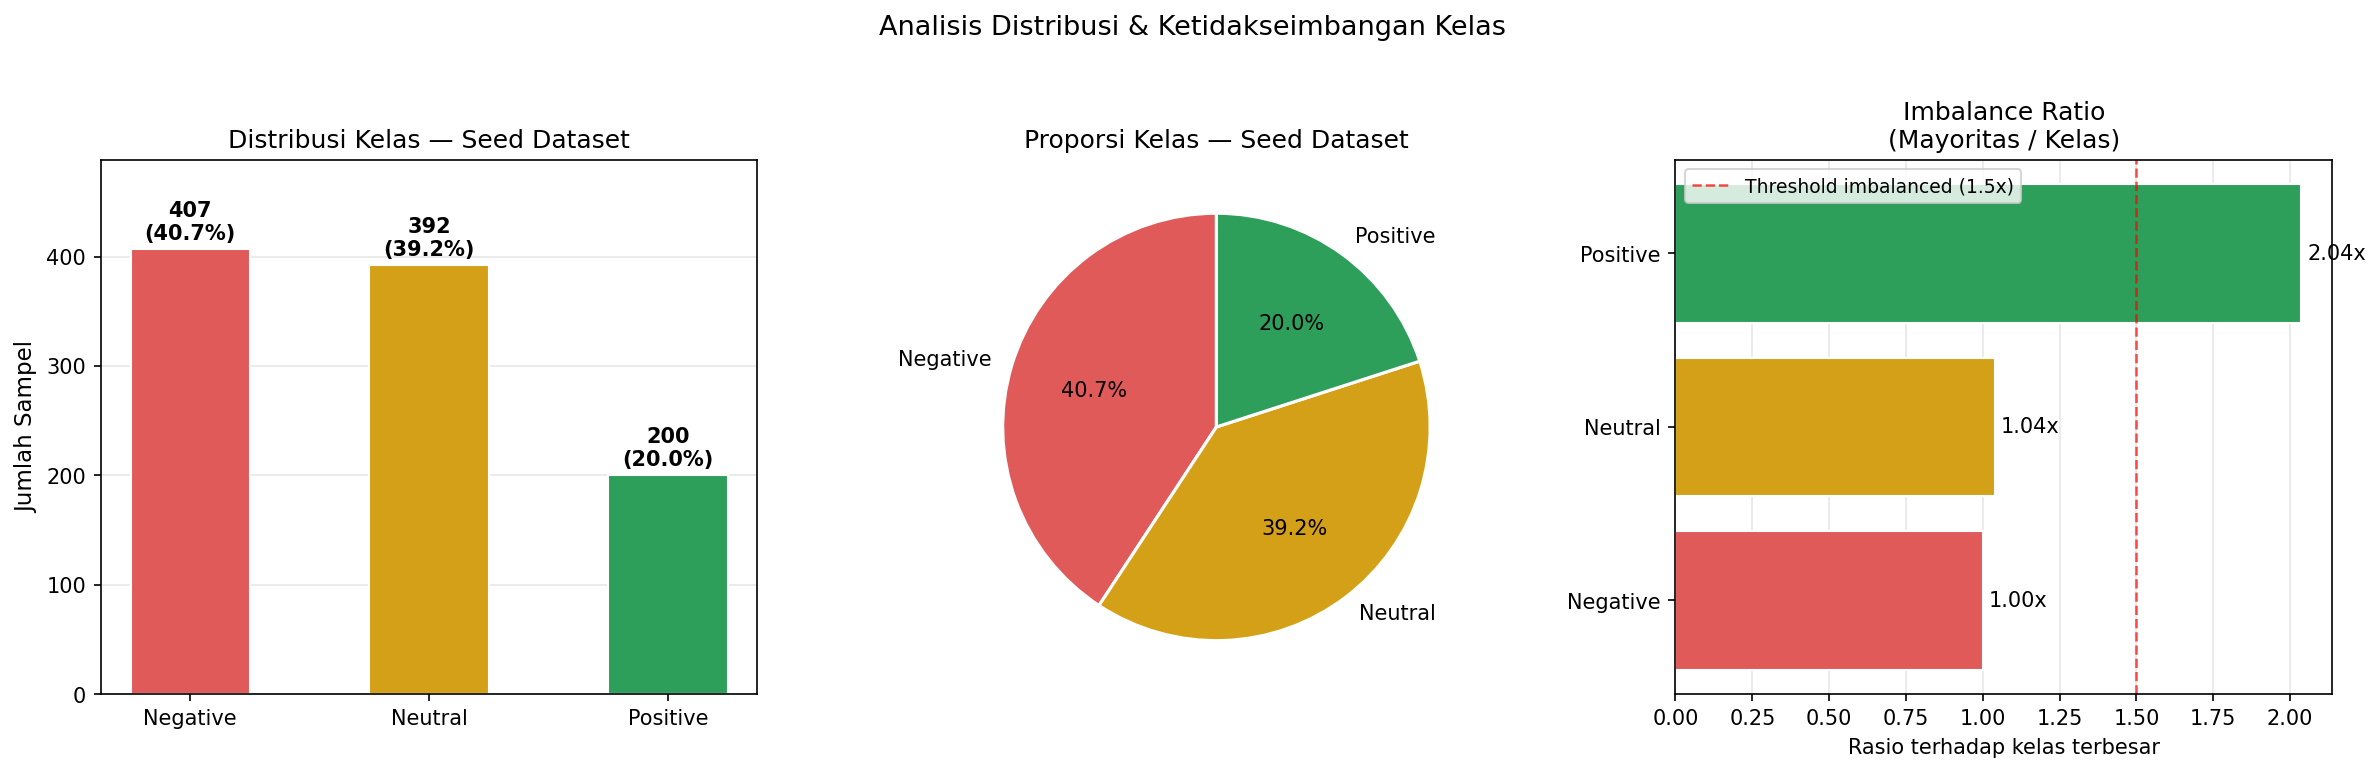


📊 Imbalance Ratio:
   Negative  : 1.00x
   Neutral   : 1.04x
   Positive  : 2.04x

   → Kelas paling minoritas: Positive
   → class_weight="balanced" diperlukan: YA


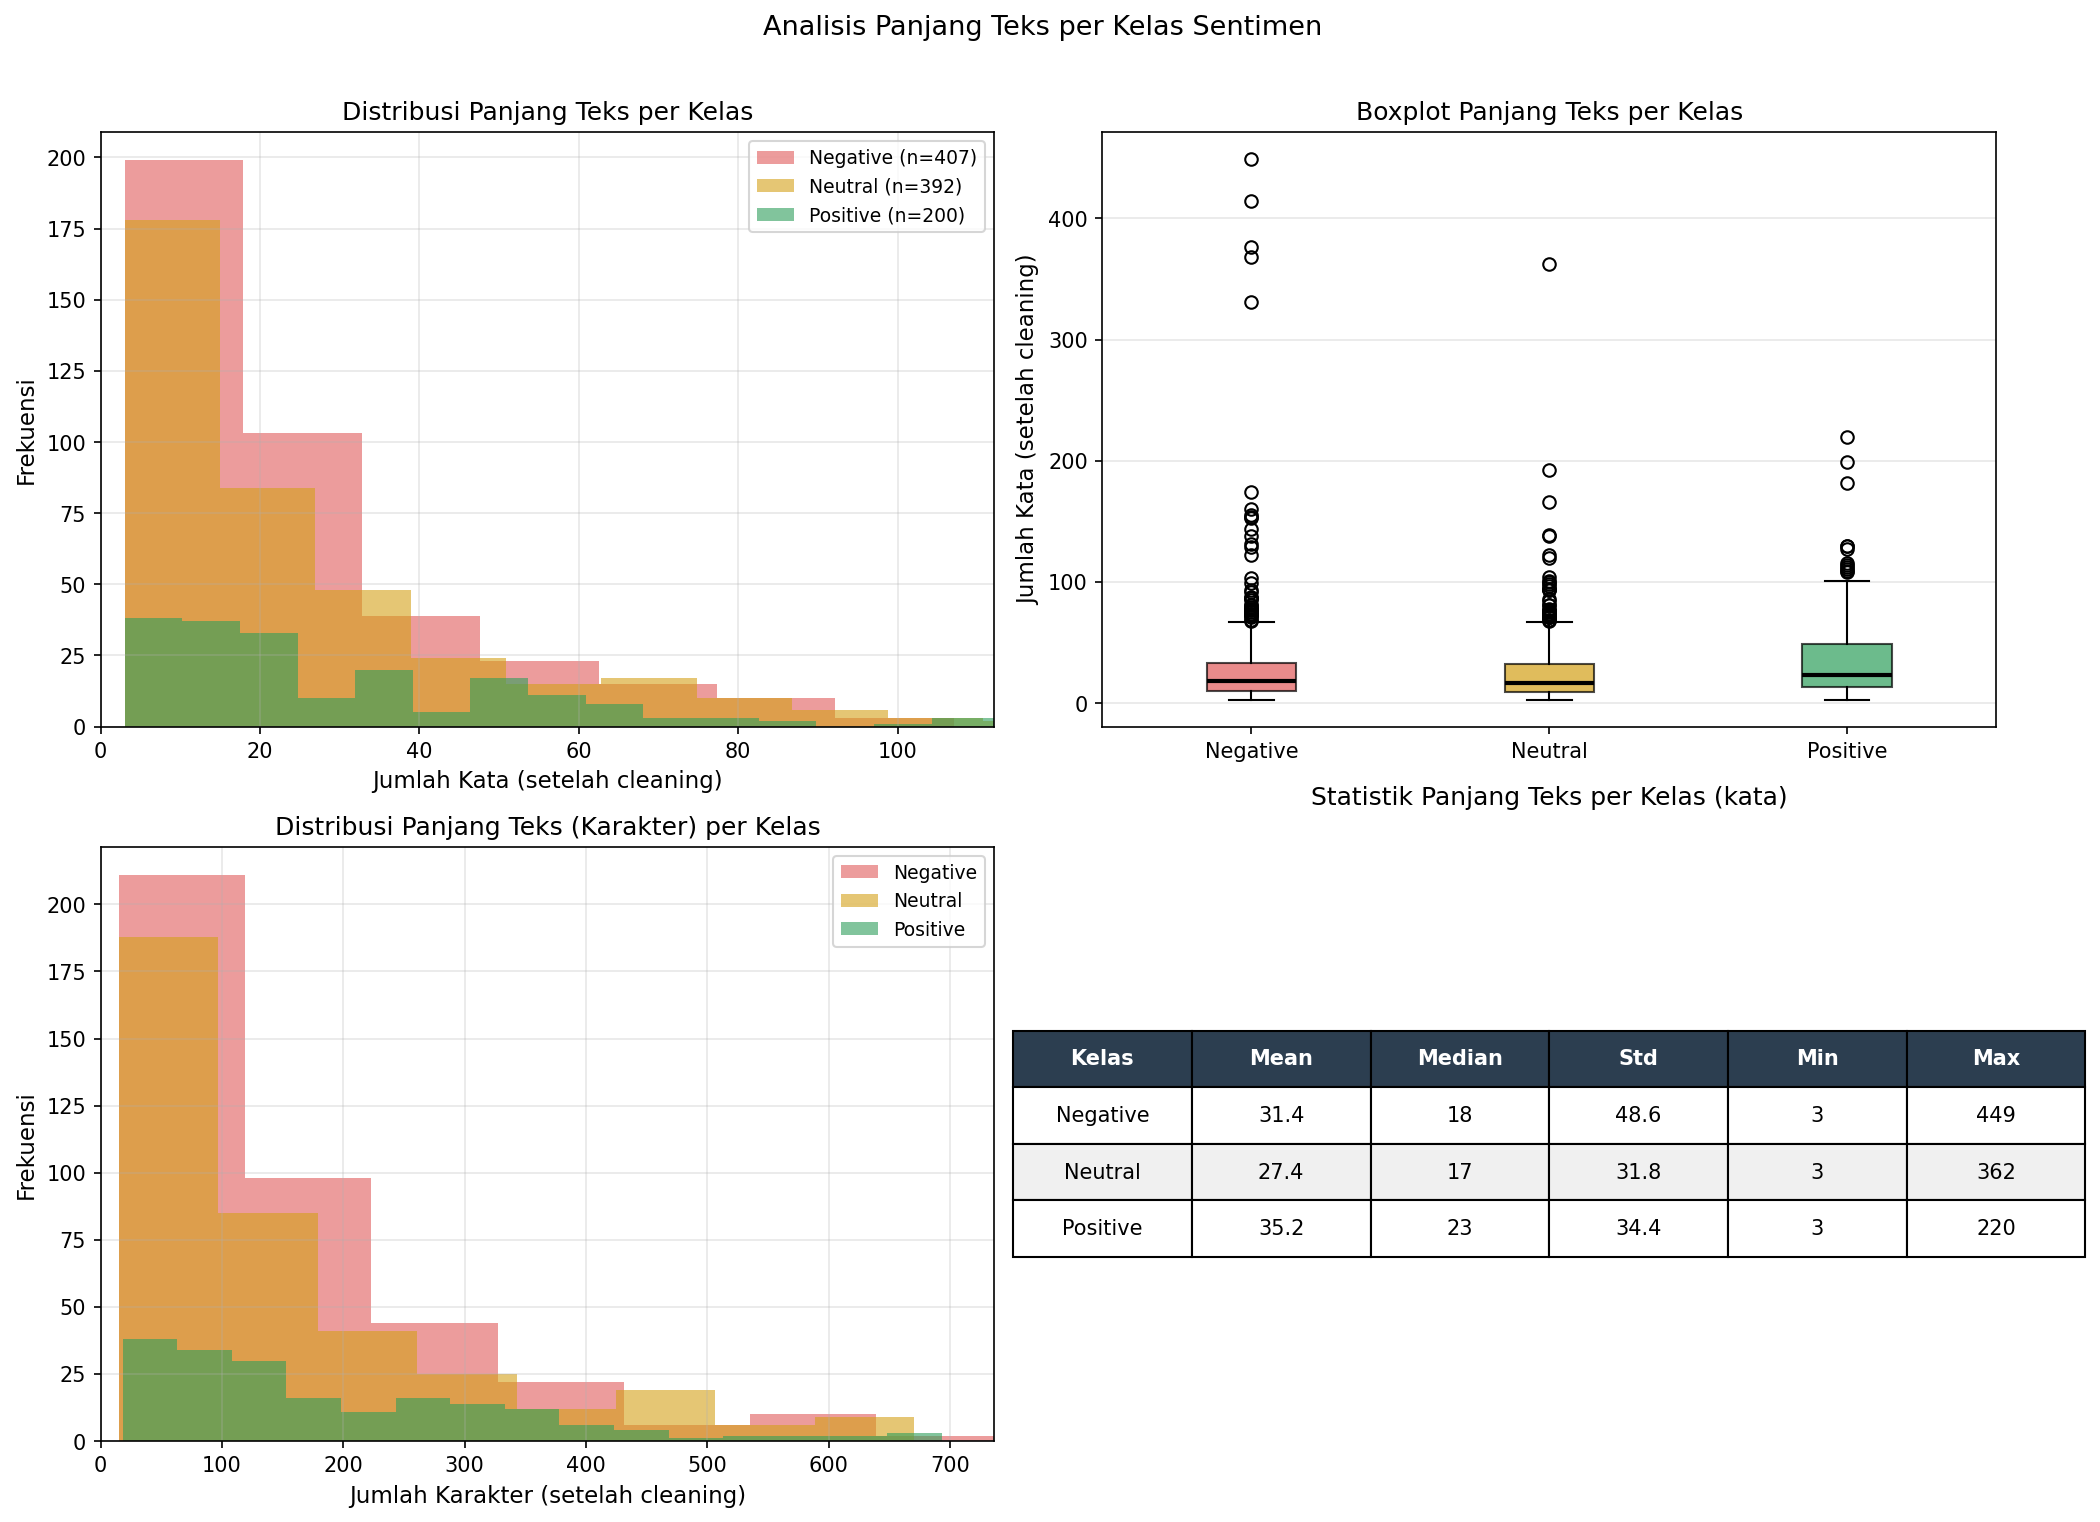

✅ Disimpan: results/eda_panjang_teks.png


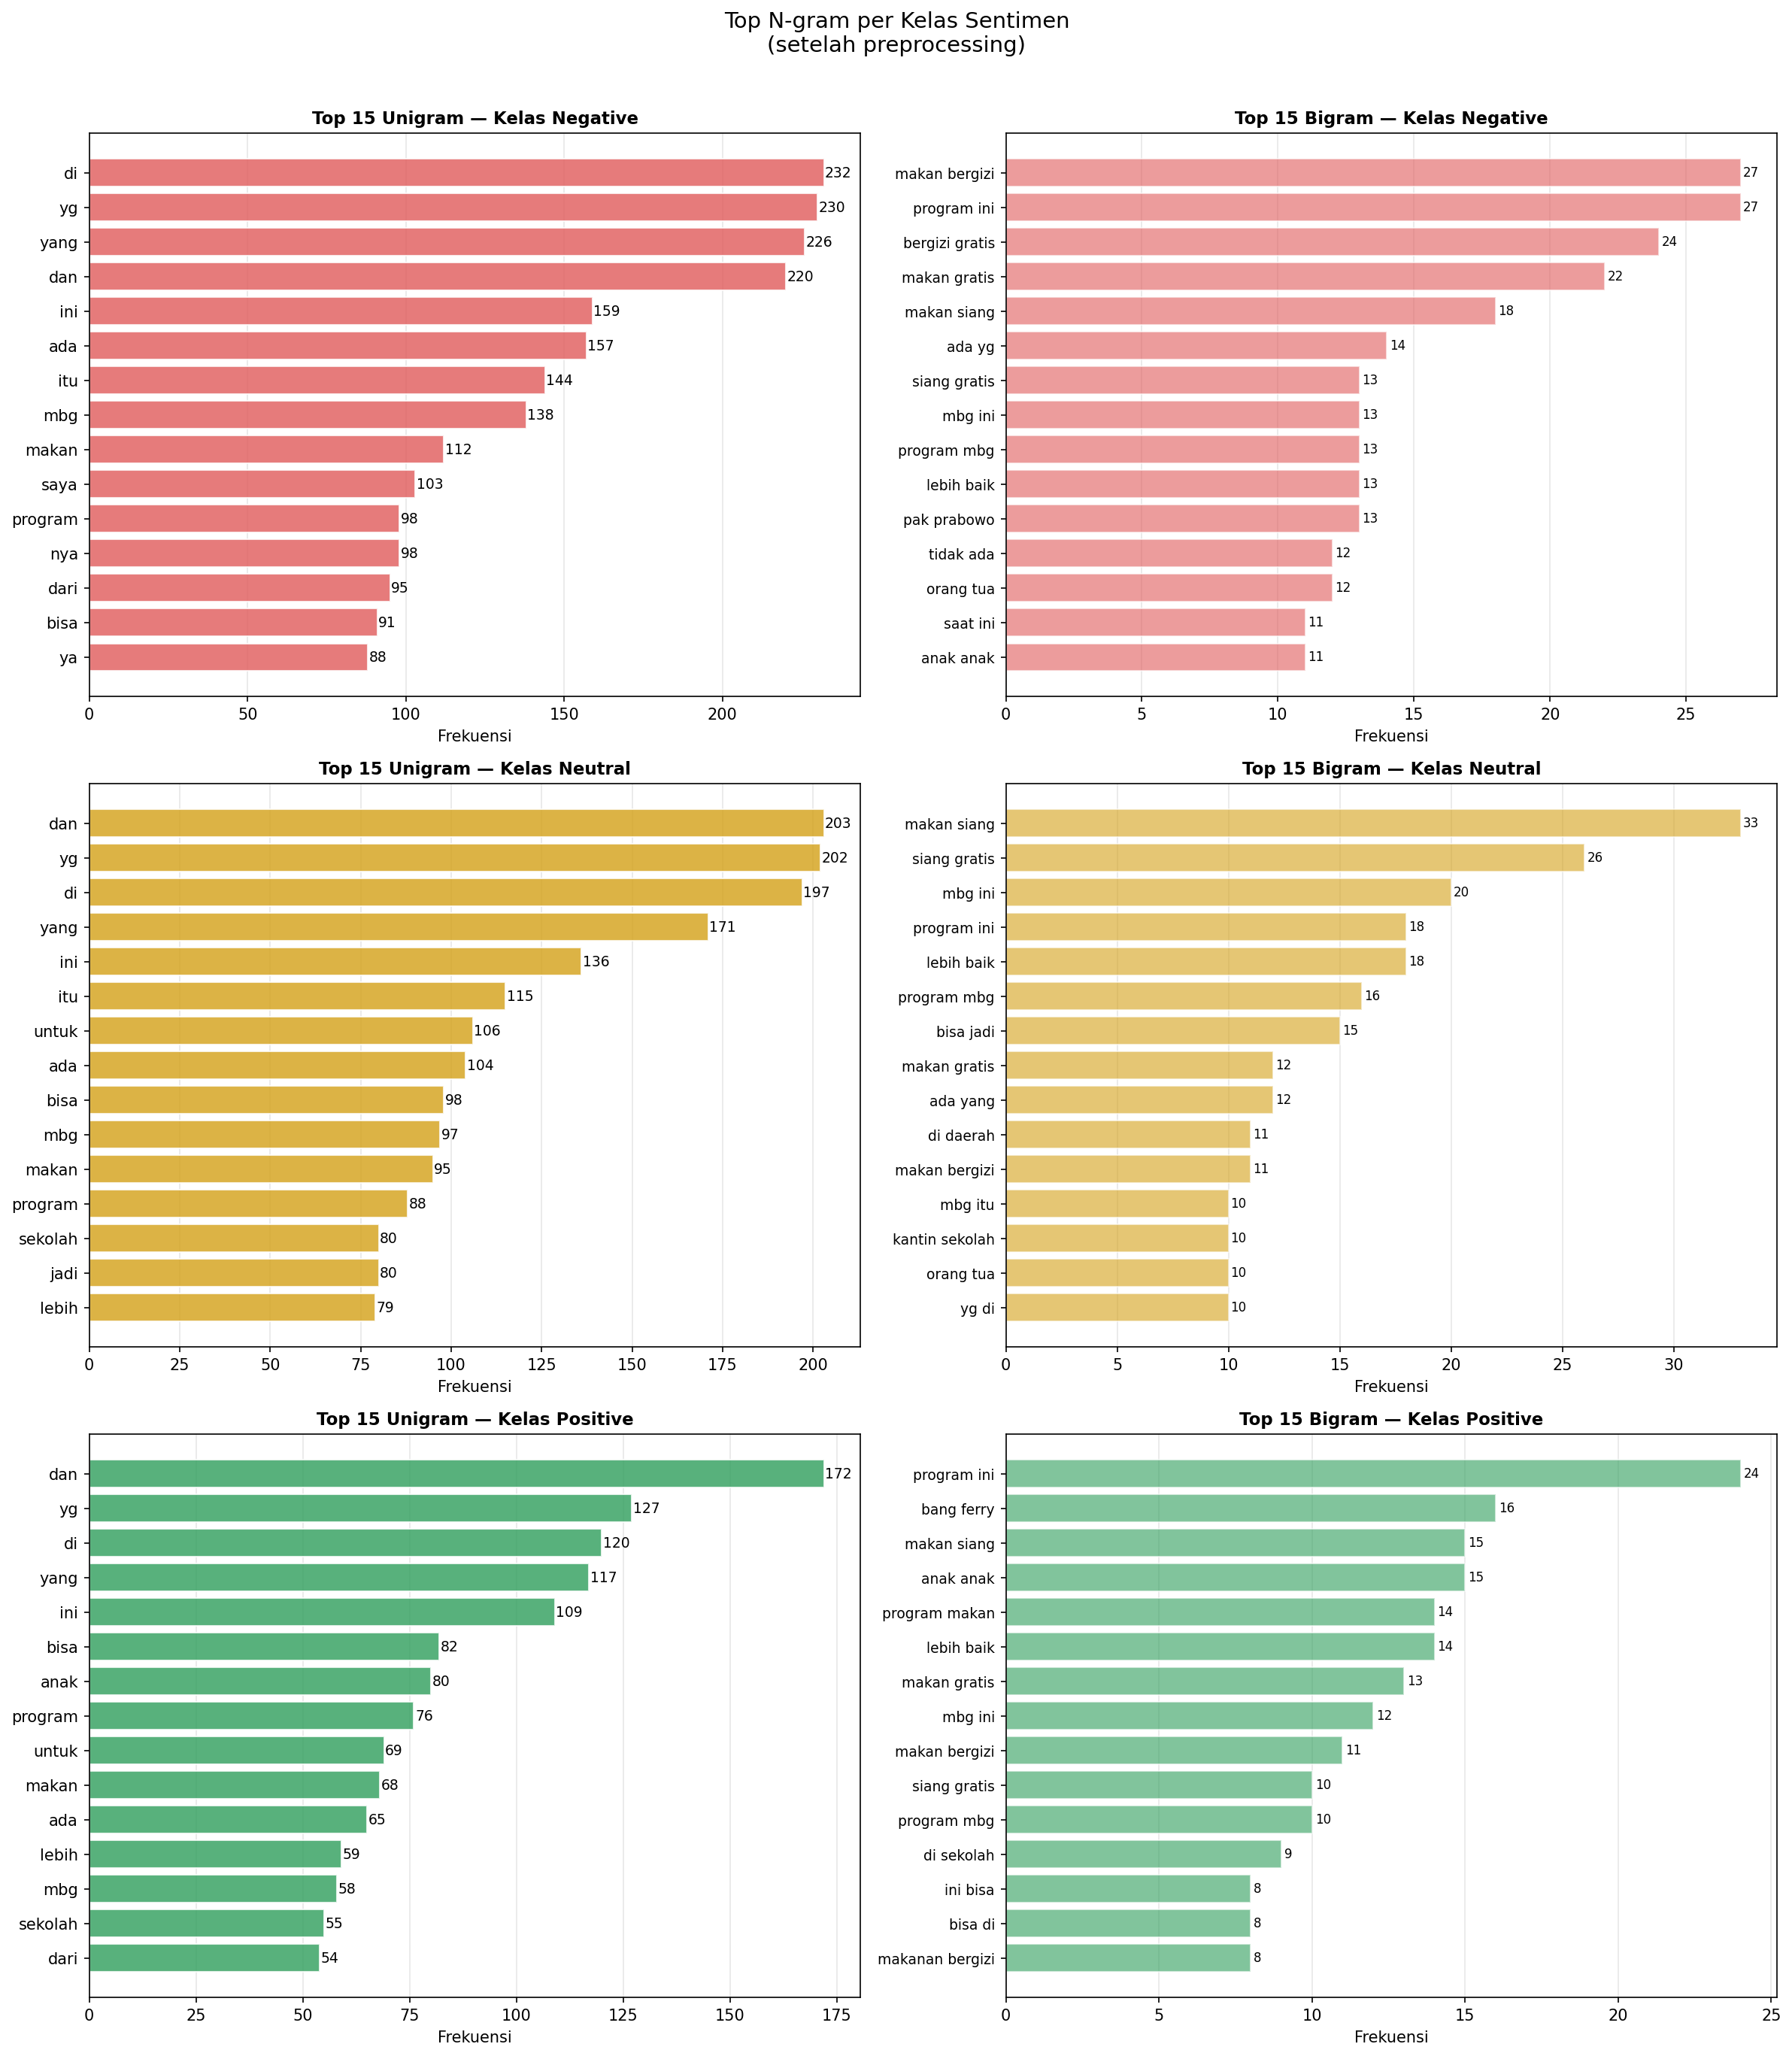

✅ Disimpan: results/eda_top_ngram.png

📊 Top 10 Unigram per Kelas (untuk tabel di paper):

  Negative:
    di                  : 232
    yg                  : 230
    yang                : 226
    dan                 : 220
    ini                 : 159
    ada                 : 157
    itu                 : 144
    mbg                 : 138
    makan               : 112
    saya                : 103

  Neutral:
    dan                 : 203
    yg                  : 202
    di                  : 197
    yang                : 171
    ini                 : 136
    itu                 : 115
    untuk               : 106
    ada                 : 104
    bisa                : 98
    mbg                 : 97

  Positive:
    dan                 : 172
    yg                  : 127
    di                  : 120
    yang                : 117
    ini                 : 109
    bisa                : 82
    anak                : 80
    program             : 76
    untuk               : 69
    maka

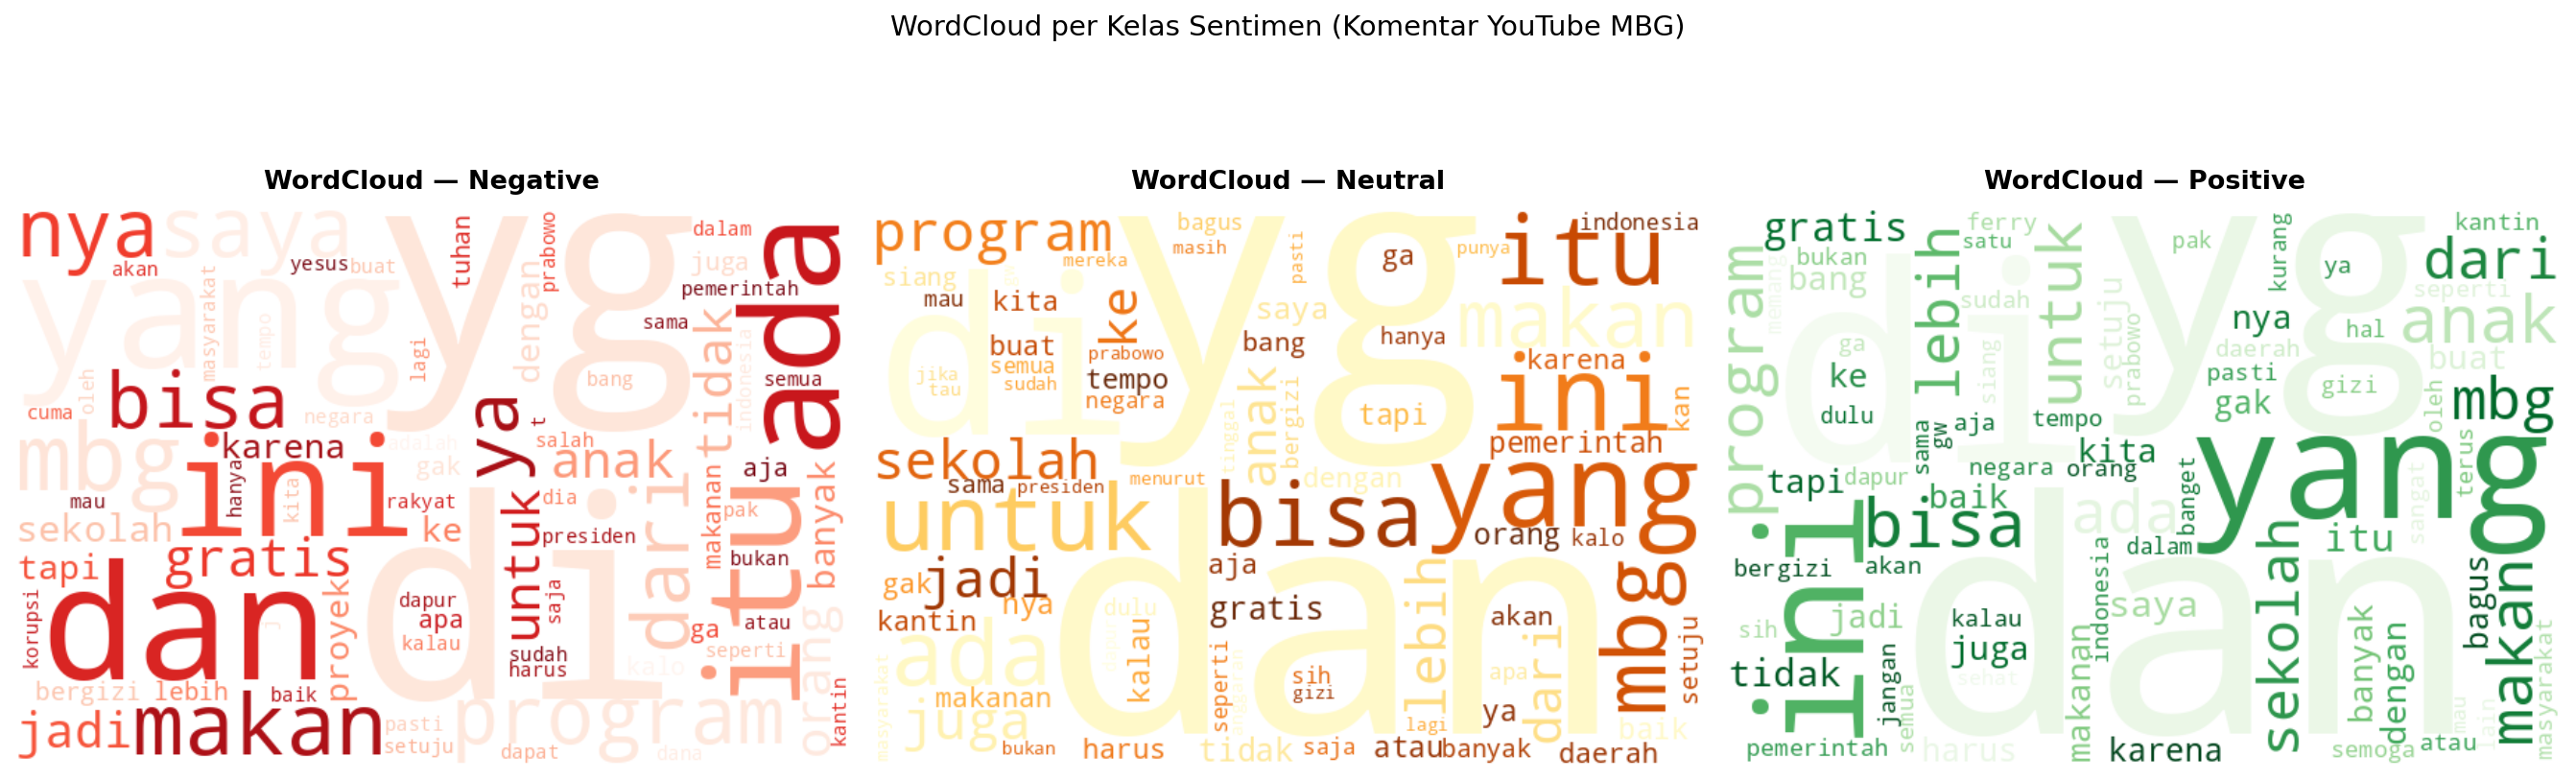

✅ Disimpan: results/eda_wordcloud.png


In [4]:
# =============================================================================
# CELL 4 — EKSPLORASI DATA (EDA)
# =============================================================================
# EDA 1 dijalankan otomatis. EDA 2-5 dibungkus dalam triple-quoted string
# (dinonaktifkan) agar tidak memperlambat eksperimen utama.
# Aktifkan masing-masing blok dengan menghapus tanda """ pembuka dan penutup.
# =============================================================================

# --- EDA 1: STATISTIK DASAR DATASET -----------------------------------------
print('=' * 65)
print('EDA 1 — STATISTIK DASAR DATASET')
print('=' * 65)

print('\n📌 SEED DATASET (sample_1000_labeled.csv)')
print(f'   Jumlah sampel  : {len(seed_df)}')
print(f'   Jumlah kolom   : {len(seed_df.columns)} -> {list(seed_df.columns)}')
print('   Missing values :')
for col in seed_df.columns:
    n_miss = seed_df[col].isna().sum()
    status = '✅' if n_miss == 0 else f'{n_miss} ({n_miss / len(seed_df) * 100:.1f}%)'
    print(f'     {col}: {status}')
print(f'   Duplikat teks       : {seed_df["text"].duplicated().sum()}')
print(f'   Duplikat text_clean : {seed_df["text_clean"].duplicated().sum()}')

print(f'\n📌 RAW/POOL DATASET (clean_comments_mbg.csv)')
print(f'   Jumlah sampel  : {len(raw_df)}')
print(f'   Jumlah kolom   : {len(raw_df.columns)} -> {list(raw_df.columns)}')
print('   Missing values :')
for col in raw_df.columns:
    n_miss = raw_df[col].isna().sum()
    print(f'     {col}: {n_miss} ({n_miss / len(raw_df) * 100:.1f}%)')
print(f'   Duplikat teks  : {raw_df["text"].duplicated().sum()}')

# Hitung statistik panjang teks
seed_df['n_char_raw']   = seed_df['text'].apply(lambda x: len(str(x)))
seed_df['n_char_clean'] = seed_df['text_clean'].apply(lambda x: len(str(x)))
seed_df['n_word_raw']   = seed_df['text'].apply(lambda x: len(str(x).split()))
seed_df['n_word_clean'] = seed_df['text_clean'].apply(lambda x: len(str(x).split()))

print('\n📏 Statistik Panjang Teks (Seed):')
stats_df = seed_df[['n_char_raw', 'n_char_clean', 'n_word_raw', 'n_word_clean']].describe().round(1)
display(stats_df)

mean_reduction = (1 - seed_df["n_word_clean"].mean() / seed_df["n_word_raw"].mean()) * 100
print(f'\n   Komentar terpendek (raw) : {seed_df["n_word_raw"].min()} kata')
print(f'   Komentar terpanjang (raw): {seed_df["n_word_raw"].max()} kata')
print(f'   Rata-rata (raw)          : {seed_df["n_word_raw"].mean():.1f} kata')
print(f'   Rata-rata (clean)        : {seed_df["n_word_clean"].mean():.1f} kata')
print(f'   Reduksi rata-rata        : {mean_reduction:.1f}%')

# Tabel distribusi label (untuk Tabel 1 paper)
print('\n📊 Distribusi Label Seed (gunakan untuk Tabel 1 paper):')
dist_df = seed_df['label_enc'].value_counts().sort_index().to_frame(name='Jumlah')
dist_df.index = [label_map[i] for i in dist_df.index]
dist_df['Persentase (%)'] = (dist_df['Jumlah'] / len(seed_df) * 100).round(1)
display(dist_df)


# --- EDA 2: DISTRIBUSI KELAS & IMBALANCE RATIO (NONAKTIF) -------------------
# Aktifkan: hapus tanda """ di bawah ini
"""
COLORS = ['#e05a5a', '#d4a017', '#2e9e5b']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
counts   = seed_df['label_enc'].value_counts().sort_index()
x_labels = [label_map[i] for i in counts.index]
bars = ax.bar(x_labels, counts.values, color=COLORS, edgecolor='white', width=0.5)
for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{cnt}\n({cnt / len(seed_df) * 100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Distribusi Kelas — Seed Dataset', fontsize=12)
ax.set_ylabel('Jumlah Sampel', fontsize=11)
ax.set_ylim(0, counts.max() * 1.2)
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)

ax = axes[1]
ax.pie(counts.values, labels=x_labels, colors=COLORS, autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('Proporsi Kelas — Seed Dataset', fontsize=12)

ax = axes[2]
majority = counts.max()
ratios   = majority / counts.values
ax.barh(x_labels, ratios, color=COLORS, edgecolor='white')
ax.axvline(x=1.5, color='red', linestyle='--', linewidth=1.2, alpha=0.7,
           label='Threshold imbalanced (1.5x)')
for i, v in enumerate(ratios):
    ax.text(v + 0.02, i, f'{v:.2f}x', va='center', fontsize=10)
ax.set_title('Imbalance Ratio\n(Mayoritas / Kelas)', fontsize=12)
ax.set_xlabel('Rasio terhadap kelas terbesar', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Analisis Distribusi & Ketidakseimbangan Kelas', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_distribusi_kelas.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'\n📊 Imbalance Ratio:')
for lbl, cnt in zip([label_map[i] for i in counts.index], counts.values):
    print(f'   {lbl:10s}: {majority / cnt:.2f}x')
print(f'   -> class_weight="balanced" diperlukan: {"YA" if majority / counts.min() > 1.5 else "Opsional"}')
"""


# --- EDA 3: DISTRIBUSI PANJANG TEKS PER KELAS (NONAKTIF) --------------------
"""
if 'n_word_clean' not in seed_df.columns:
    seed_df['n_word_clean'] = seed_df['text_clean'].apply(lambda x: len(str(x).split()))
if 'n_char_clean' not in seed_df.columns:
    seed_df['n_char_clean'] = seed_df['text_clean'].apply(lambda x: len(str(x)))

COLORS = ['#e05a5a', '#d4a017', '#2e9e5b']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
for lbl, color in zip([0, 1, 2], COLORS):
    subset = seed_df[seed_df['label_enc'] == lbl]['n_word_clean']
    ax.hist(subset, bins=30, alpha=0.6, color=color,
            label=f'{label_map[lbl]} (n={len(subset)})', edgecolor='none')
ax.set_xlabel('Jumlah Kata (setelah cleaning)', fontsize=11)
ax.set_ylabel('Frekuensi', fontsize=11)
ax.set_title('Distribusi Panjang Teks per Kelas', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, seed_df['n_word_clean'].quantile(0.97))

ax = axes[0, 1]
data_box = [seed_df[seed_df['label_enc'] == lbl]['n_word_clean'].values for lbl in [0, 1, 2]]
bp = ax.boxplot(data_box, labels=[label_map[i] for i in [0, 1, 2]],
                patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('Jumlah Kata (setelah cleaning)', fontsize=11)
ax.set_title('Boxplot Panjang Teks per Kelas', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 0]
for lbl, color in zip([0, 1, 2], COLORS):
    subset = seed_df[seed_df['label_enc'] == lbl]['n_char_clean']
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=label_map[lbl], edgecolor='none')
ax.set_xlabel('Jumlah Karakter (setelah cleaning)', fontsize=11)
ax.set_ylabel('Frekuensi', fontsize=11)
ax.set_title('Distribusi Panjang Teks (Karakter) per Kelas', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, seed_df['n_char_clean'].quantile(0.97))

ax = axes[1, 1]
ax.axis('off')
stats_rows = []
for lbl in [0, 1, 2]:
    sub = seed_df[seed_df['label_enc'] == lbl]['n_word_clean']
    stats_rows.append([label_map[lbl], f'{sub.mean():.1f}', f'{sub.median():.0f}',
                       f'{sub.std():.1f}', f'{sub.min():.0f}', f'{sub.max():.0f}'])
col_headers = ['Kelas', 'Mean', 'Median', 'Std', 'Min', 'Max']
table = ax.table(cellText=stats_rows, colLabels=col_headers, loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1.2, 2.0)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f0f0f0')
ax.set_title('Statistik Panjang Teks per Kelas (kata)', fontsize=12, pad=20)

plt.suptitle('Analisis Panjang Teks per Kelas Sentimen', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_panjang_teks.png', dpi=200, bbox_inches='tight')
plt.show()
"""


# --- EDA 4: TOP N-GRAM PER KELAS (NONAKTIF) ---------------------------------
"""
from collections import Counter

def get_top_ngrams(texts, n=1, top_k=15):
    \"\"\"Menghitung n-gram paling sering dari daftar teks.\"\"\"
    all_ngrams = []
    for text in texts:
        tokens = str(text).split()
        if n == 1:
            all_ngrams.extend(tokens)
        else:
            all_ngrams.extend([' '.join(tokens[i:i + n]) for i in range(len(tokens) - n + 1)])
    return Counter(all_ngrams).most_common(top_k)

COLORS = ['#e05a5a', '#d4a017', '#2e9e5b']
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
for row_idx, lbl in enumerate([0, 1, 2]):
    subset_texts = seed_df[seed_df['label_enc'] == lbl]['text_clean'].values
    color = COLORS[lbl]
    for col_idx, n_gram in enumerate([1, 2]):
        ax = axes[row_idx, col_idx]
        top_ng = get_top_ngrams(subset_texts, n=n_gram, top_k=15)
        words, freqs = zip(*top_ng)
        y_pos = range(len(words))
        ax.barh(y_pos, freqs, color=color, alpha=0.8 if n_gram == 1 else 0.6, edgecolor='white')
        ax.set_yticks(y_pos); ax.set_yticklabels(words, fontsize=9 if n_gram == 2 else 10)
        ax.invert_yaxis()
        ax.set_xlabel('Frekuensi', fontsize=10)
        ax.set_title(f'Top 15 {"Uni" if n_gram == 1 else "Bi"}gram — {label_map[lbl]}',
                     fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x'); ax.set_axisbelow(True)
        for i, freq in enumerate(freqs):
            ax.text(freq + 0.1, i, str(freq), va='center', fontsize=8)
plt.suptitle('Top N-gram per Kelas Sentimen (setelah preprocessing)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_top_ngram.png', dpi=200, bbox_inches='tight')
plt.show()
"""


# --- EDA 5: WORDCLOUD PER KELAS (NONAKTIF, perlu pip install wordcloud) ------
"""
try:
    from wordcloud import WordCloud
    WC_AVAILABLE = True
except ImportError:
    print('wordcloud belum terinstall. Jalankan: !pip install wordcloud -q')
    WC_AVAILABLE = False

if WC_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    WC_COLORS = ['Reds', 'YlOrBr', 'Greens']
    for idx, lbl in enumerate([0, 1, 2]):
        ax = axes[idx]
        subset_text = ' '.join(seed_df[seed_df['label_enc'] == lbl]['text_clean'].values)
        if len(subset_text.strip()) == 0:
            ax.text(0.5, 0.5, 'Tidak ada teks', ha='center', va='center'); ax.axis('off')
            continue
        wc = WordCloud(width=600, height=400, background_color='white',
                       colormap=WC_COLORS[idx], max_words=100).generate(subset_text)
        ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
        ax.set_title(f'Word Cloud — {label_map[lbl]}', fontsize=13, fontweight='bold')
    plt.suptitle('Word Cloud per Kelas Sentimen', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/eda_wordcloud.png', dpi=200, bbox_inches='tight')
    plt.show()
"""


---
## 5. Vektorisasi TF-IDF

Mengubah teks menjadi representasi vektor numerik menggunakan TF-IDF.

**Keputusan desain penting:**  
TF-IDF di-*fit* **hanya pada seed dataset** untuk menghindari *data leakage* dari pool.
Konsekuensinya: term yang hanya muncul di pool menjadi zero vector (OOV) —
perlu dicatat sebagai limitasi dalam paper.


In [5]:
# =============================================================================
# CELL 5 — VEKTORISASI TF-IDF
# =============================================================================
# TF-IDF di-fit HANYA pada seed dataset untuk mencegah data leakage.
# Implikasi: term OOV di pool -> zero vector (dicatat sebagai limitasi).
# =============================================================================

tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE,
    sublinear_tf=True    # log(1 + tf) meredam efek term frekuensi tinggi
)

# Fit HANYA pada seed — jangan gunakan raw_df di sini
tfidf.fit(seed_df['text_clean'])

X_seed = tfidf.transform(seed_df['text_clean'])
y_seed = seed_df['label_enc'].values
X_pool = tfidf.transform(raw_df['text_clean'])

print('✅ Vektorisasi TF-IDF selesai')
print(f'   X_seed shape : {X_seed.shape}')
print(f'   X_pool shape : {X_pool.shape}')
print(f'   Vocabulary   : {len(tfidf.vocabulary_)} term')

# --- ANALISIS OOV (Out-of-Vocabulary) ----------------------------------------
# Zero-vector = sampel yang seluruh tokennya tidak ada di vocabulary seed
zero_rows_pool = (X_pool.sum(axis=1) == 0).sum()
print(f'\n⚠️  Pool zero-vector (OOV) : {zero_rows_pool} / {X_pool.shape[0]}'
      f' ({zero_rows_pool / X_pool.shape[0] * 100:.1f}%)')
print('   Sampel OOV tidak informatif bagi Margin Sampling — catat sebagai limitasi.')
print('\n🔍 Contoh 20 fitur pertama TF-IDF vocabulary:')
print(tfidf.get_feature_names_out()[:20])


✅ TF-IDF Vectorization selesai
   X_seed shape : (999, 5000)
   X_pool shape : (7967, 5000)

⚠️  Pool zero-vector rows (OOV) : 4 / 7967 (0.1%)
   (Sampel ini tidak informatif bagi Margin Sampling — catat sebagai limitasi)

🔍 Sample features TF-IDF:
['abah' 'abal' 'abang' 'acuan' 'ad' 'ada' 'ada ahli' 'ada aja' 'ada anak'
 'ada anggaran' 'ada apa' 'ada banyak' 'ada beberapa' 'ada berapa'
 'ada berita' 'ada bocor' 'ada dan' 'ada dana' 'ada di' 'ada evaluasi']


---
## 6. Pembagian Dataset (3-Way Stratified Split)

Seed dataset (1.000 sampel berlabel) dibagi menjadi tiga subset dengan stratifikasi kelas:

| Subset | Proporsi | Fungsi |
|---|---|---|
| `initial_train` | 60% (~600) | Set latih awal model baseline |
| `oracle_pool` | 20% (~200) | Pool kandidat untuk kueri Active Learning |
| `test_fixed` | 20% (~200) | Set uji tetap — **tidak disentuh selama AL** |

> **Mengapa split dari DataFrame, bukan sparse matrix?**
> Agar teks komentar asli ikut terbawa ke oracle pool, sehingga annotator
> manusia bisa **membaca** komentar sebelum memberi label (kunci HITL nyata).


In [6]:
# =============================================================================
# CELL 6 — PEMBAGIAN DATASET 3-WAY (60 / 20 / 20)
# =============================================================================
# Split dari seed_df (DataFrame) bukan sparse matrix agar teks asli tersedia
# di oracle pool untuk proses anotasi HITL.
# =============================================================================

# --- Langkah 1: Pisahkan test set (20%) -------------------------------------
temp_df, test_df = train_test_split(
    seed_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=seed_df['label_enc']
)

# --- Langkah 2: Sisa dibagi 75/25 -> train=60%, oracle_pool=20% -------------
train_df, pool_df = train_test_split(
    temp_df,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=temp_df['label_enc']
)

# Reset index setelah split
train_df = train_df.reset_index(drop=True)
pool_df  = pool_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# --- Transformasi ke sparse matrix ------------------------------------------
X_train_base  = tfidf.transform(train_df['text_clean'])
X_test_fixed  = tfidf.transform(test_df['text_clean'])
X_oracle_pool = tfidf.transform(pool_df['text_clean'])

y_train_base  = train_df['label_enc'].values
y_test_fixed  = test_df['label_enc'].values
y_oracle_pool = pool_df['label_enc'].values

# --- Setup oracle pool untuk AL loop ----------------------------------------
# X_pool dan y_pool adalah alias yang digunakan di seluruh eksperimen AL
X_pool           = X_oracle_pool
y_pool           = y_oracle_pool
POOL_HAS_LABELS  = True    # Pool memiliki ground truth untuk evaluasi
WEAK_ORACLE_MODE = False   # Tidak menggunakan weak oracle

# df_unl_template: DataFrame dengan teks asli <- kunci untuk HITL
# Annotator perlu membaca teks sebelum melabeli
df_unl_template = pool_df[['text', 'text_clean']].copy()

print('✅ Pembagian dataset 3-way selesai')
print(f'   initial_train : {X_train_base.shape[0]} sampel')
print(f'   oracle_pool   : {X_pool.shape[0]} sampel  <- teks tersedia untuk labeling')
print(f'   test_fixed    : {X_test_fixed.shape[0]} sampel  <- dikunci, tidak disentuh AL')
print(f'\n   POOL_HAS_LABELS  : {POOL_HAS_LABELS}')
print(f'   WEAK_ORACLE_MODE : {WEAK_ORACLE_MODE}')

print('\n📊 Distribusi label — initial_train:')
for k, v in zip(*np.unique(y_train_base, return_counts=True)):
    print(f'   {label_map[k]:10s}: {v:4d}  ({v / len(y_train_base) * 100:.1f}%)')

print('\n📊 Distribusi label — oracle_pool:')
for k, v in zip(*np.unique(y_pool, return_counts=True)):
    print(f'   {label_map[k]:10s}: {v:4d}  ({v / len(y_pool) * 100:.1f}%)')

print('\n🔍 Preview teks oracle pool (yang akan dilabeli):')
display(pool_df[['text', 'label_enc']].head(3))
print('\n🔒 Test set dikunci — tidak digunakan untuk training atau query.')


✅ 3-Way Split 60/20/20 selesai (dengan teks asli di pool)
   initial_train : 599 sampel
   oracle_pool   : 200 sampel  ← teks tersedia untuk labeling
   test_fixed    : 200 sampel

   POOL_HAS_LABELS  : True
   WEAK_ORACLE_MODE : False

📊 Distribusi — initial_train:
   Negative  :  244  (40.7%)
   Neutral   :  235  (39.2%)
   Positive  :  120  (20.0%)

📊 Distribusi — oracle_pool:
   Negative  :   81  (40.5%)
   Neutral   :   79  (39.5%)
   Positive  :   40  (20.0%)

🔍 Preview teks di oracle pool (yang akan kamu labeli):


,text,label_enc
0,"Ya setuju sih ada imbalan jasa diproyek ini, t...",0
1,"Biaya gimana, 10rb bakal bengkak kan, kalo kan...",1
2,? @wafiealdora666-ff5kg judiari siapa yah.raky...,1



🔒 Test set dikunci


EDA 6 — DISTRIBUSI SEED vs ORACLE POOL (Post-Split)


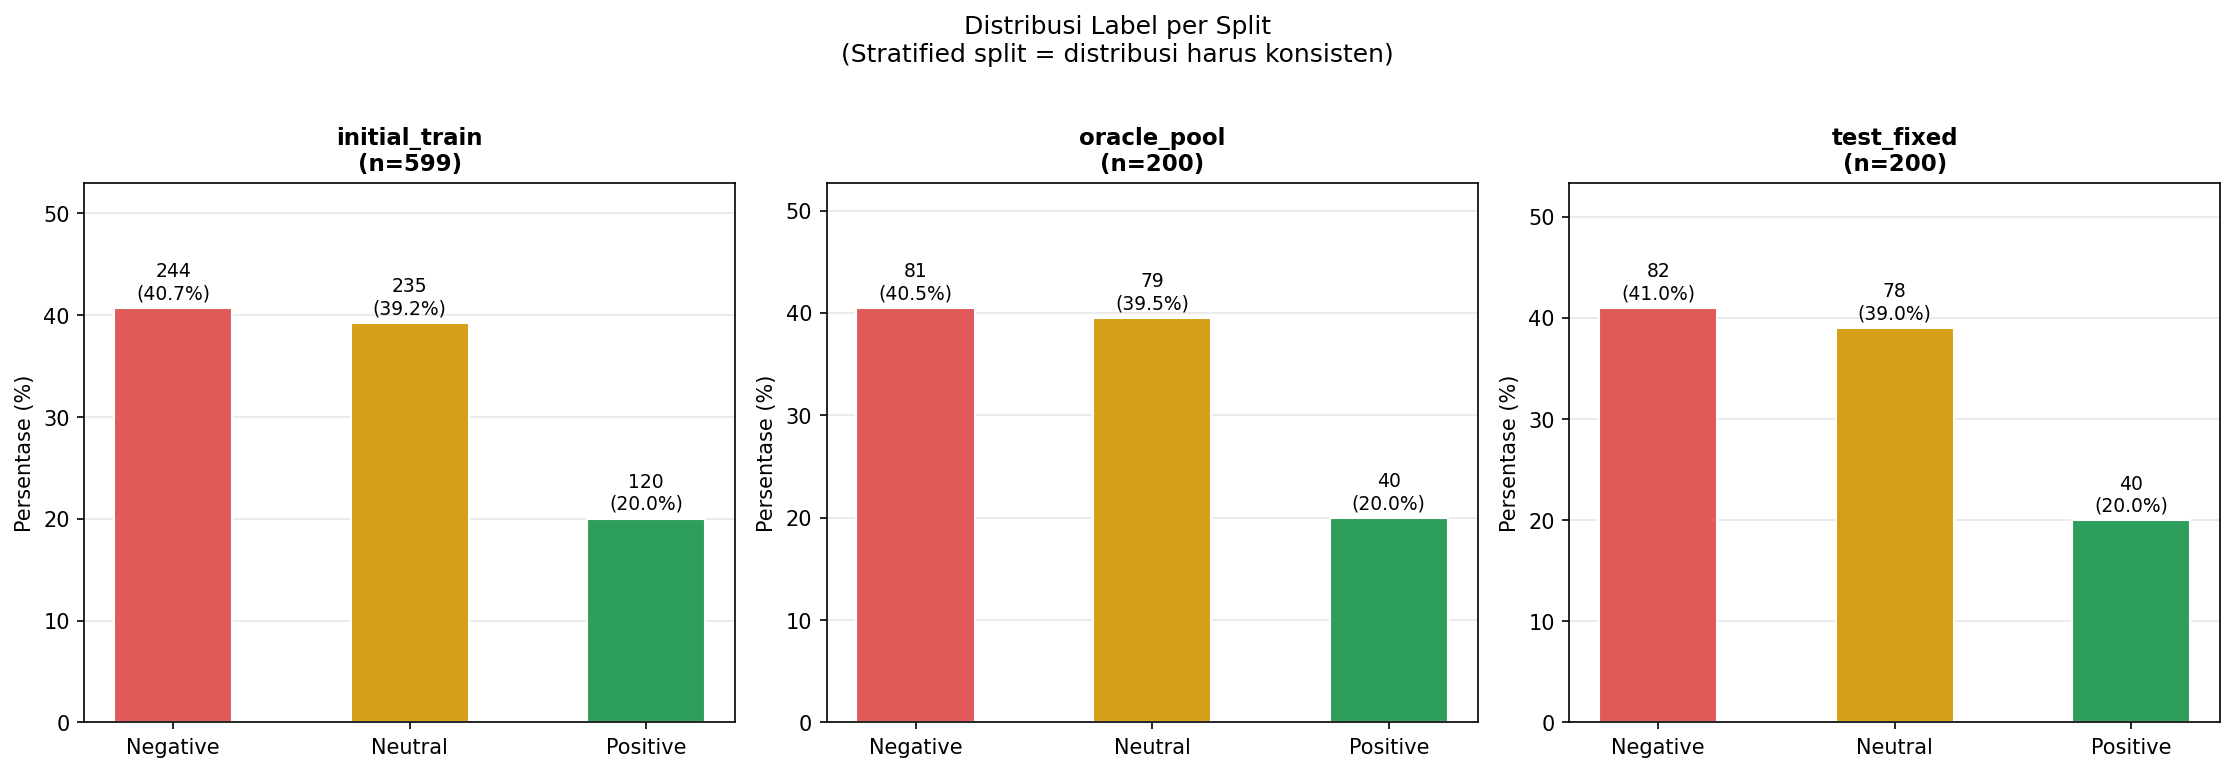


📊 Proporsi Kelas per Split (harus ~serupa — bukti stratified split berhasil):
  Kelas           initial_train      oracle_pool       test_fixed
--------------------------------------------------------------
  Negative                40.7%            40.5%            41.0%
  Neutral                 39.2%            39.5%            39.0%
  Positive                20.0%            20.0%            20.0%

📊 Out-of-Vocabulary (OOV) Analysis:
   TF-IDF vocabulary dibangun dari 599 sampel training
   Zero-vector di initial_train : 0 (0.0%)
   Zero-vector di test_fixed    : 0 (0.0%)
   Zero-vector di oracle_pool   : 0 (0.0%)

   ✅ Zero-vector rendah = distribusi linguistik antar split serupa
   ⚠️  Zero-vector tinggi = indikasi covariate shift (perlu didiskusikan di paper)


In [7]:
# =============================================================================
# EDA 6 — VERIFIKASI DISTRIBUSI ANTAR SPLIT (COVARIATE SHIFT CHECK)
# =============================================================================
# Stratified split harus menghasilkan distribusi kelas yang serupa di ketiga
# subset. Perbedaan signifikan mengindikasikan covariate shift.
# =============================================================================

COLORS = ['#e05a5a', '#d4a017', '#2e9e5b']

print('=' * 65)
print('EDA 6 — DISTRIBUSI LABEL PER SPLIT (Post-Split)')
print('=' * 65)

splits = {
    'initial_train': y_train_base,
    'oracle_pool'  : y_pool,
    'test_fixed'   : y_test_fixed,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (split_name, y_arr) in zip(axes, splits.items()):
    counts   = pd.Series(y_arr).value_counts().sort_index()
    x_labels = [label_map[i] for i in counts.index]
    bars = ax.bar(x_labels, counts.values / len(y_arr) * 100,
                  color=COLORS, edgecolor='white', width=0.5)
    for bar, cnt in zip(bars, counts.values):
        pct = cnt / len(y_arr) * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{cnt}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{split_name}\n(n={len(y_arr)})', fontsize=11, fontweight='bold')
    ax.set_ylabel('Persentase (%)', fontsize=10)
    ax.set_ylim(0, max(counts.values / len(y_arr) * 100) * 1.3)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)

plt.suptitle('Distribusi Label per Split\n(Stratified split -> distribusi harus konsisten)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_distribusi_per_split.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Tabel proporsi per split ------------------------------------------------
print('\n📊 Proporsi kelas per split (harus ~serupa — bukti stratified split berhasil):')
print(f'  {"Kelas":<12}', end='')
for name in splits:
    print(f' {name:>16}', end='')
print()
print('-' * 62)
for lbl in [0, 1, 2]:
    print(f'  {label_map[lbl]:<12}', end='')
    for y_arr in splits.values():
        pct = (y_arr == lbl).sum() / len(y_arr) * 100
        print(f' {pct:>15.1f}%', end='')
    print()

# --- OOV analysis per split --------------------------------------------------
print('\n📊 Out-of-Vocabulary (OOV) Analysis:')
print(f'   TF-IDF vocabulary dibangun dari {X_train_base.shape[0]} sampel training.')
zero_train = (X_train_base.sum(axis=1) == 0).sum()
zero_test  = (X_test_fixed.sum(axis=1) == 0).sum()
zero_pool  = (X_pool.sum(axis=1) == 0).sum()
print(f'   Zero-vector di initial_train : {zero_train} ({zero_train / X_train_base.shape[0] * 100:.1f}%)')
print(f'   Zero-vector di test_fixed    : {zero_test} ({zero_test / X_test_fixed.shape[0] * 100:.1f}%)')
print(f'   Zero-vector di oracle_pool   : {zero_pool} ({zero_pool / X_pool.shape[0] * 100:.1f}%)')
print('\n   ✅ Zero-vector rendah -> distribusi linguistik antar split serupa.')
print('   ⚠️  Zero-vector tinggi -> indikasi covariate shift (perlu didiskusikan di paper).')


---
## 7. Fungsi Evaluasi Model

Fungsi `evaluate_model()` digunakan di semua loop eksperimen (AL, Random, Simulated)
untuk menghitung metrik secara konsisten.


In [8]:
# =============================================================================
# CELL 7 — FUNGSI EVALUASI MODEL
# =============================================================================

def evaluate_model(model, X_test, y_test, model_name='Model', verbose=True):
    """
    Mengevaluasi model klasifikasi dan mengembalikan dictionary metrik.

    Menghitung: accuracy, precision, recall (macro), F1 macro,
    F1 weighted, serta F1 per kelas (Negative, Neutral, Positive).

    Args:
        model      : Classifier sklearn yang sudah di-fit.
        X_test     : Matriks fitur test (sparse atau dense).
        y_test     : Label ground truth.
        model_name : Label untuk ditampilkan pada output.
        verbose    : Jika True, cetak metrik ke stdout.

    Returns:
        dict: Dictionary berisi semua nilai metrik.
    """
    y_pred = model.predict(X_test)

    acc         = accuracy_score(y_test, y_pred)
    prec        = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec         = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro    = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    # Gunakan .get() agar aman jika suatu kelas tidak muncul di prediksi
    f1_neg = report.get('0', {}).get('f1-score', 0.0)
    f1_neu = report.get('1', {}).get('f1-score', 0.0)
    f1_pos = report.get('2', {}).get('f1-score', 0.0)

    if verbose:
        print(f'  [{model_name}]')
        print(f'  Accuracy  : {acc:.4f}')
        print(f'  Precision : {prec:.4f}  |  Recall : {rec:.4f}')
        print(f'  F1 Macro  : {f1_macro:.4f}  |  F1 Weighted : {f1_weighted:.4f}')
        print(f'  F1 per kelas -> Neg: {f1_neg:.4f}  Neu: {f1_neu:.4f}  Pos: {f1_pos:.4f}')

    return {
        'model_name':   model_name,
        'accuracy':     acc,
        'precision':    prec,
        'recall':       rec,
        'f1_macro':     f1_macro,
        'f1_weighted':  f1_weighted,
        'f1_neg':       f1_neg,
        'f1_neu':       f1_neu,
        'f1_pos':       f1_pos,
    }


print('✅ evaluate_model() siap digunakan')


✅ evaluate_model() siap digunakan


---
## 8. Fungsi Anotasi Human-in-the-Loop

Fungsi `human_label_cli()` mengelola proses pemberian label dalam dua mode:
- **Simulasi** (`SIMULATION_MODE=True`): menggunakan oracle label + noise terprogram
- **HITL Nyata** (`SIMULATION_MODE=False`): meminta input label dari peneliti via CLI


In [9]:
# =============================================================================
# CELL 8 — FUNGSI ANOTASI HUMAN-IN-THE-LOOP
# =============================================================================

def human_label_cli(query_idx, unlabeled_df, oracle_labels=None,
                    max_samples=5, noise_rate=0.15, simulation=True,
                    random_state=42):
    """
    Mengelola proses anotasi label dalam dua mode operasi.

    Mode Simulasi (simulation=True):
        Mensimulasikan anotator manusia menggunakan oracle_labels sebagai ground truth.
        Label yang salah diterapkan dengan probabilitas `noise_rate`, dipilih acak dari
        kelas lain, untuk merepresentasikan ketidakpastian anotasi manusia.
        -> Reprodusibel (dikendalikan oleh random_state).
        -> Cocok untuk eksperimen yang dilaporkan di paper.

    Mode HITL Nyata (simulation=False):
        Menampilkan teks komentar dan meminta input label dari pengguna via CLI.
        Mendukung opsi 's' (skip) untuk komentar ambigu atau tidak relevan.

    Args:
        query_idx     : Array indeks sampel dari strategi query.
        unlabeled_df  : DataFrame pool dengan kolom 'text'.
        oracle_labels : Array label ground truth (wajib jika simulation=True).
        max_samples   : Jumlah maksimum sampel dilabeli per iterasi.
        noise_rate    : Probabilitas kesalahan label [0.0, 1.0].
        simulation    : True = mode simulasi, False = HITL nyata.
        random_state  : Seed untuk reprodusibilitas noise simulasi.

    Returns:
        selected_idx : np.array indeks sampel yang berhasil dilabeli.
        new_labels   : np.array label hasil anotasi.
    """
    rng    = np.random.default_rng(random_state)
    n      = min(max_samples, len(query_idx))
    chosen = query_idx[:n]
    new_labels = []

    if simulation:
        # --- MODE SIMULASI ---------------------------------------------------
        if oracle_labels is None:
            raise ValueError('oracle_labels wajib diisi saat simulation=True')
        for idx in chosen:
            true_label = int(oracle_labels[idx])
            if rng.random() < noise_rate:
                # Simulasi kesalahan anotasi: pilih kelas lain secara acak
                other_classes = [c for c in [0, 1, 2] if c != true_label]
                new_labels.append(int(rng.choice(other_classes)))
            else:
                new_labels.append(true_label)

    else:
        # --- MODE CLI NYATA --------------------------------------------------
        print('\n' + '=' * 60)
        print('SESI PELABELAN MANUSIA')
        print('Label: 0=Negative  1=Neutral  2=Positive  s=skip')
        print('=' * 60)
        valid_chosen = []
        for idx in chosen:
            text = (unlabeled_df.iloc[idx]['text']
                    if 'text' in unlabeled_df.columns
                    else '(teks tidak tersedia)')
            print(f'\n[{idx}] {text[:200]}')
            while True:
                inp = input('Label (0/1/2/s): ').strip().lower()
                if inp in ('0', '1', '2'):
                    new_labels.append(int(inp))
                    valid_chosen.append(idx)
                    break
                elif inp == 's':
                    break  # Skip: tidak ditambahkan ke labeled set
                else:
                    print('  Input tidak valid. Masukkan 0, 1, 2, atau s.')
        chosen = valid_chosen

    return np.array(chosen), np.array(new_labels)


print('✅ human_label_cli() siap digunakan')
print(f'   Mode aktif : {"SIMULASI (reprodusibel)" if SIMULATION_MODE else "CLI NYATA (HITL)"}')


✅ human_label_cli() siap digunakan
   Mode aktif : CLI NYATA (HITL)


---
## 9. Model Baseline

Melatih dua model pada `initial_train` sebagai titik referensi sebelum AL dimulai.

- **SVM Linear** — model utama yang digunakan di semua loop AL
- **Logistic Regression** — pembanding tambahan

Nilai F1 Macro baseline SVM menjadi referensi peningkatan di setiap iterasi.


In [10]:
# =============================================================================
# CELL 9 — MODEL BASELINE (SVM + LOGISTIC REGRESSION)
# =============================================================================
# Model dilatih pada initial_train (60% seed dataset).
# Hasil evaluasi menjadi titik referensi (iterasi 0) untuk perbandingan AL.
# =============================================================================

# --- Definisi model ----------------------------------------------------------
svm_model = SVC(
    kernel='linear',
    C=1.0,
    class_weight='balanced',    # Kompensasi class imbalance
    probability=True,           # Diperlukan untuk decision_function Margin Sampling
    random_state=RANDOM_STATE
)

lr_model = LogisticRegression(
    C=1.0,
    solver='saga',
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# --- Training ----------------------------------------------------------------
print('🚀 Training SVM Linear...')
svm_model.fit(X_train_base, y_train_base)

print('🚀 Training Logistic Regression...')
lr_model.fit(X_train_base, y_train_base)

# --- Evaluasi baseline -------------------------------------------------------
print('\n' + '=' * 60)
print('📊 EVALUASI BASELINE')
print('=' * 60)

baseline_metrics_svm = evaluate_model(
    svm_model, X_test_fixed, y_test_fixed,
    model_name='SVM Linear (Baseline)'
)
print()
baseline_metrics_lr = evaluate_model(
    lr_model, X_test_fixed, y_test_fixed,
    model_name='Logistic Regression (Baseline)'
)

print(f'\n🎯 Baseline F1 Macro (SVM) : {baseline_metrics_svm["f1_macro"]:.4f}')
print(f'   Dilatih pada {X_train_base.shape[0]} sampel initial_train')
print(f'   Oracle pool  : {X_pool.shape[0]} sampel dengan label ground truth ✅')


🚀 Training SVM Linear...
🚀 Training Logistic Regression...

📊 EVALUASI BASELINE
  [SVM Linear (Baseline)]
  Accuracy  : 0.5300
  Precision : 0.5307  |  Recall : 0.5088
  F1 Macro  : 0.5154  |  F1 Weighted : 0.5286
  F1 per class  → Neg: 0.5605  Neu: 0.5349  Pos: 0.4507

  [Logistic Regression (Baseline)]
  Accuracy  : 0.5250
  Precision : 0.5240  |  Recall : 0.5084
  F1 Macro  : 0.5142  |  F1 Weighted : 0.5242
  F1 per class  → Neg: 0.5556  Neu: 0.5212  Pos: 0.4658

🎯 Baseline F1 Macro (SVM) : 0.5154
   (Dilatih pada 599 sampel initial_train)
   Oracle pool: 200 sampel dengan label ASLI ✅


---
## 10. Fungsi Strategi Query

Dua strategi pemilihan sampel yang dibandingkan dalam eksperimen:

**Pure Margin Sampling** (strategi utama, Settles 2009):

$$\phi_{MS}(x) = f^{(1)}(x) - f^{(2)}(x), \quad x^* = \underset{x \in U}{\text{argmin}} \; \phi_{MS}(x)$$

Sampel dengan margin keputusan terkecil = paling ambigu = diprioritaskan.

**Random Sampling** (baseline): pemilihan acak tanpa mempertimbangkan ketidakpastian model.


In [11]:
# =============================================================================
# CELL 10 — FUNGSI STRATEGI QUERY
# =============================================================================

def svm_margin_sampling(model, X_pool, n_samples=10):
    """
    Pure Margin Sampling untuk multiclass SVM (Settles, 2009).

    Rumus:
        phi_MS(x) = f^(1)(x) - f^(2)(x)
        x* = argmin_{x in U} phi_MS(x)

    f^(1) dan f^(2) adalah nilai decision function tertinggi dan tertinggi-kedua.
    Sampel dengan margin TERKECIL paling ambigu dan diprioritaskan.

    Args:
        model     : SVC sklearn yang sudah di-fit.
        X_pool    : Matriks fitur pool kandidat (sparse).
        n_samples : Jumlah sampel yang dipilih.

    Returns:
        np.array: Indeks n_samples sampel dengan margin terkecil.
    """
    scores        = model.decision_function(X_pool)
    sorted_scores = np.sort(scores, axis=1)[:, ::-1]    # Urutkan menurun
    margin        = sorted_scores[:, 0] - sorted_scores[:, 1]
    return np.argsort(margin)[:n_samples]


def random_query(X_pool, n_samples=10, seed=None):
    """
    Random Sampling sebagai baseline tanpa strategi pemilihan.

    Args:
        X_pool    : Matriks fitur pool (digunakan untuk mengetahui ukuran pool).
        n_samples : Jumlah sampel yang dipilih.
        seed      : Seed untuk reprodusibilitas.

    Returns:
        np.array: Indeks n_samples sampel acak.
    """
    rng = np.random.default_rng(seed)
    return rng.choice(X_pool.shape[0], size=n_samples, replace=False)


print('✅ Fungsi strategi query siap')
print('   - svm_margin_sampling()  <- strategi utama (Margin Sampling)')
print('   - random_query()         <- baseline acak')
print()
print('   Rumus Margin Sampling:')
print('   phi_MS(x) = f^(1)(x) - f^(2)(x)')
print('   x* = argmin_{x in U} phi_MS(x)')


✅ Query strategy functions siap
   - svm_margin_sampling  ← UTAMA 
   - random_query         ← baseline

   Rumus: phi_MS(x) = f^(1)(x) - f^(2)(x)
   Pilih: x* = argmin_{x in U} margin(x)


---
## 11. Panduan Anotasi — Baca Sebelum Memulai Labeling

> Bagian ini relevan jika `SIMULATION_MODE = False` (HITL nyata).

Setiap komentar diberi salah satu dari tiga label:

| Label | Kode | Kriteria |
|---|---|---|
| **Negatif** | `0` | Ketidaksetujuan, kekecewaan, kritik, atau penolakan terhadap MBG |
| **Netral** | `1` | Informatif/faktual tanpa polaritas jelas, atau ekspresi ambigu |
| **Positif** | `2` | Dukungan, apresiasi, harapan positif, atau kepuasan terhadap MBG |

**Contoh pelabelan:**
- `"program ini bagus banget semoga lancar"` → **2 (Positif)**
- `"katanya makan gratis tapi kualitasnya buruk"` → **0 (Negatif)**
- `"program mbg diluncurkan januari 2025"` → **1 (Netral)**
- `"buang buang anggaran negara"` → **0 (Negatif)**

**Aturan:**
- Fokus pada **sikap terhadap MBG**, bukan konten berita umum
- Ragu antara Netral dan kelas lain → pilih **Netral**
- Ketik `s` untuk skip komentar tidak relevan / tidak dapat dipahami
- Jangan mengubah label setelah dikirim — konsistensi lebih penting

> ⏱️ Estimasi waktu: **15–25 menit** (15 iterasi × 5 komentar = 75 komentar total)


---
## 12. Active Learning Loop — Human-in-the-Loop (HITL)

Eksperimen utama: 15 iterasi AL dengan **Pure Margin Sampling**.

**Alur setiap iterasi:**
1. **Train** — latih SVM pada labeled set saat ini
2. **Evaluate** — ukur F1 Macro pada test set tetap
3. **Query** — pilih QUERY_SIZE sampel paling ambigu (margin terkecil)
4. **Label** — annotator memberi label (HITL atau simulasi)
5. **Update** — tambahkan sampel berlabel ke labeled set
6. **Remove** — hapus sampel terpilih (dan yang di-skip) dari pool

Pre-evaluation. Model diuji dulu menggunakan data yang ada di awal iterasi, baru disuntik data baru di akhir iterasi.


In [12]:
# =============================================================================
# CELL 11 — ACTIVE LEARNING LOOP (AL-HITL)
# =============================================================================
# Strategi query  : Pure Margin Sampling
# Jumlah iterasi  : N_ITER (15)
# Sampel per iter : QUERY_SIZE (5) -> 75 sampel tambahan total
# Mode anotasi    : SIMULATION_MODE (False = HITL nyata)
# =============================================================================

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# --- Inisialisasi variabel tracking ------------------------------------------
history_al    = []    # Metrik evaluasi setiap iterasi
svm_al_models = []    # Snapshot model setiap iterasi (untuk visualisasi)
skip_log      = []    # Log jumlah sampel dilabeli vs di-skip per iterasi

# --- Inisialisasi labeled set dan pool ---------------------------------------
# Salinan independen agar tidak mengubah data baseline
X_lbl  = X_train_base.copy()
y_lbl  = y_train_base.copy()
X_unl  = X_pool.copy()
y_unl  = y_pool.copy()
df_unl = df_unl_template.copy()

# Model AL dimulai dari bobot baseline (sudah di-fit pada initial_train)
svm_al = copy.deepcopy(svm_model)

print('🚀 Memulai Active Learning — Pure Margin Sampling')
print(f'   Iterasi     : {N_ITER}  |  Query/iter: {QUERY_SIZE}')
print(f'   Mode        : {"SIMULASI" if SIMULATION_MODE else "HITL NYATA"}')
print()

for i in range(N_ITER):
    print(f'{"=" * 55}')
    print(f'ITERASI {i + 1:2d}/{N_ITER}  '
          f'|  Labeled: {X_lbl.shape[0]}  '
          f'|  Pool sisa: {X_unl.shape[0]}')

    if X_unl.shape[0] < 1:
        print('⚠️  Pool habis -> stopping')
        break

    # --- 1. TRAIN ------------------------------------------------------------
    svm_al.fit(X_lbl, y_lbl)
    svm_al_models.append(copy.deepcopy(svm_al))

    # --- 2. EVALUATE ---------------------------------------------------------
    metrics = evaluate_model(
        svm_al, X_test_fixed, y_test_fixed,
        model_name=f'AL Iter {i + 1}', verbose=True
    )
    metrics['iteration']    = i + 1
    metrics['labeled_size'] = X_lbl.shape[0]
    history_al.append(metrics)

    # --- 3. QUERY — Pure Margin Sampling ------------------------------------
    # v9 fix: ambil tepat QUERY_SIZE (hapus buffer x2 dari v8)
    n_candidate = min(QUERY_SIZE, X_unl.shape[0])
    query_idx   = svm_margin_sampling(svm_al, X_unl, n_samples=n_candidate)

    # Tampilkan distribusi prediksi kelas kandidat (monitoring)
    pred_dist = svm_al.predict(X_unl[query_idx])
    cls_dist  = {label_map[c]: int((pred_dist == c).sum())
                 for c in [0, 1, 2] if (pred_dist == c).sum() > 0}
    print(f'   -> Kandidat {n_candidate} | Distribusi prediksi: {cls_dist}')

    # --- 4. LABELING ---------------------------------------------------------
    oracle_subset = y_unl[query_idx]
    selected_idx, new_labels = human_label_cli(
        query_idx, df_unl,
        oracle_labels=oracle_subset,
        max_samples=n_candidate,
        noise_rate=ANNOTATION_NOISE,
        simulation=SIMULATION_MODE,
        random_state=RANDOM_STATE + i
    )

    # --- 5. LOG SKIP ---------------------------------------------------------
    skipped_idx = np.array([q for q in query_idx if q not in selected_idx])
    n_labeled   = len(selected_idx)
    n_skipped   = len(skipped_idx)
    skip_log.append({'iteration': i + 1, 'labeled': n_labeled, 'skipped': n_skipped})
    print(f'   -> Dilabeli: {n_labeled}  |  Di-skip: {n_skipped}')

    # --- 6. UPDATE LABELED SET -----------------------------------------------
    if n_labeled > 0:
        X_lbl = vstack([X_lbl, X_unl[selected_idx]])
        y_lbl = np.concatenate([y_lbl, new_labels])

    # --- 7. HAPUS DARI POOL (labeled + skipped) ------------------------------
    # Sampel yang di-skip juga dihapus untuk menghindari query berulang
    all_to_remove = np.union1d(selected_idx, skipped_idx).astype(int)
    mask          = np.ones(X_unl.shape[0], dtype=bool)
    mask[all_to_remove] = False
    X_unl  = X_unl[mask]
    y_unl  = y_unl[mask]
    df_unl = df_unl.iloc[mask].reset_index(drop=True)

    print(f'   Pool sisa: {X_unl.shape[0]}')

# --- Ringkasan akhir ---------------------------------------------------------
print()
print('✅ Active Learning selesai')
n_new = X_lbl.shape[0] - X_train_base.shape[0]
print(f'   Sampel berlabel awal  : {X_train_base.shape[0]}')
print(f'   Sampel baru dilabeli  : {n_new}')
print(f'   Total berlabel akhir  : {X_lbl.shape[0]}')

df_skip   = pd.DataFrame(skip_log)
tot_skip  = df_skip['skipped'].sum()
tot_label = df_skip['labeled'].sum()
skip_rate = (tot_skip / (tot_skip + tot_label) * 100
             if (tot_skip + tot_label) > 0 else 0)
print(f'\n📊 Statistik Skip:')
print(f'   Total dilabeli : {tot_label}')
print(f'   Total di-skip  : {tot_skip}')
print(f'   Skip rate      : {skip_rate:.1f}%')
print('   (Skip rate tinggi mengindikasikan Margin Sampling berhasil')
print('    memilih sampel yang ambigu secara semantik)')
display(df_skip)


🚀 Active Learning — Pure Margin Sampling (HITL)
   Iterasi: 15  |  Query/iter: 5
   Mode   : HITL NYATA

ITERASI  1/15  |  Labeled: 599  |  Pool sisa: 200
  [AL Iter 1]
  Accuracy  : 0.5300
  Precision : 0.5307  |  Recall : 0.5088
  F1 Macro  : 0.5154  |  F1 Weighted : 0.5286
  F1 per class  → Neg: 0.5605  Neu: 0.5349  Pos: 0.4507
   → Kandidat 5 | Pred dist: {'Negative': 3, 'Neutral': 2}

SESI PELABELAN MANUSIA
Label: 0=Negative  1=Neutral  2=Positive  s=skip

[131] mau tau cara agar MBG berhasil, STOP dulu semua, bentuk tim gizi yang benar2 ahli gizi dan bentuk pengawas, training semua karyawan MBG. jangan takut/malu mengeroksi pekerjaan yg tidak sempurna
Label (0/1/2/s): 1

[115] Padahal dari 1 kasus ini bisa lohh nyiptain lapangan pekerjaan dgn biaya produksi kecil..
Label (0/1/2/s): 2

[173] Sepakat sama bg Ferry sih ganti program makan bergizi gratis ke kantin bersubsidi,toh budget yg disediain lebih dikit dari makan bergizi gratis,dari sisi perencanaan dan pelaksanaan lebih simp

,iteration,labeled,skipped
0,1,5,0
1,2,4,1
2,3,3,2
3,4,3,2
4,5,3,2
5,6,5,0
6,7,5,0
7,8,4,1
8,9,4,1
9,10,2,3


---
## 13. Random Sampling Loop (Baseline)

Pemilihan sampel acak sebagai pembanding yang jujur untuk AL-HITL.
Kondisi awal identik dengan AL loop (seed, labeled set, pool).


In [13]:
# =============================================================================
# CELL 12 — RANDOM SAMPLING LOOP (BASELINE)
# =============================================================================
# Pemilihan sampel acak — tanpa mempertimbangkan ketidakpastian model.
# Kondisi identik dengan AL-HITL untuk perbandingan yang adil.
# =============================================================================

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

history_random    = []
svm_random_models = []

X_lbl_r = X_train_base.copy()
y_lbl_r = y_train_base.copy()
X_unl_r = X_pool.copy()
y_unl_r = y_pool.copy()

svm_random = copy.deepcopy(svm_model)

print('🎲 Memulai Random Sampling (baseline)...')

for i in range(N_ITER):
    # Train & evaluate
    svm_random.fit(X_lbl_r, y_lbl_r)
    svm_random_models.append(copy.deepcopy(svm_random))

    metrics = evaluate_model(
        svm_random, X_test_fixed, y_test_fixed,
        model_name=f'Random Iter {i + 1}', verbose=False
    )
    metrics['iteration']    = i + 1
    metrics['labeled_size'] = X_lbl_r.shape[0]
    history_random.append(metrics)
    print(f'  Iter {i + 1:2d} | Labeled: {X_lbl_r.shape[0]} | F1 Macro: {metrics["f1_macro"]:.4f}')

    if X_unl_r.shape[0] < QUERY_SIZE:
        break

    # Query acak
    rand_idx = random_query(X_unl_r, n_samples=QUERY_SIZE, seed=RANDOM_STATE + i)
    y_new_r  = y_unl_r[rand_idx]

    # Update labeled set & hapus dari pool
    X_lbl_r = vstack([X_lbl_r, X_unl_r[rand_idx]])
    y_lbl_r = np.concatenate([y_lbl_r, y_new_r])

    mask = np.ones(X_unl_r.shape[0], dtype=bool)
    mask[rand_idx] = False
    X_unl_r = X_unl_r[mask]
    y_unl_r = y_unl_r[mask]

print('\n✅ Random Sampling selesai')


🎲 Starting Random Sampling (baseline)...
  Iter  1 | Labeled: 599 | F1 Macro: 0.5154
  Iter  2 | Labeled: 604 | F1 Macro: 0.5102
  Iter  3 | Labeled: 609 | F1 Macro: 0.5183
  Iter  4 | Labeled: 614 | F1 Macro: 0.5111
  Iter  5 | Labeled: 619 | F1 Macro: 0.5141
  Iter  6 | Labeled: 624 | F1 Macro: 0.5091
  Iter  7 | Labeled: 629 | F1 Macro: 0.4968
  Iter  8 | Labeled: 634 | F1 Macro: 0.5150
  Iter  9 | Labeled: 639 | F1 Macro: 0.5048
  Iter 10 | Labeled: 644 | F1 Macro: 0.4910
  Iter 11 | Labeled: 649 | F1 Macro: 0.4938
  Iter 12 | Labeled: 654 | F1 Macro: 0.4928
  Iter 13 | Labeled: 659 | F1 Macro: 0.5031
  Iter 14 | Labeled: 664 | F1 Macro: 0.4984
  Iter 15 | Labeled: 669 | F1 Macro: 0.4977

✅ Random Sampling selesai


---
## 14. Simulated AL Loop (Oracle — Batas Atas Teoritis)

Margin Sampling dengan label oracle sempurna (tanpa noise anotasi).
Ini merepresentasikan **batas atas teoritis** performa AL — strategi query identik
dengan AL-HITL, tetapi mengasumsikan anotator dengan akurasi 100%.


In [14]:
# =============================================================================
# CELL 13 — SIMULATED AL LOOP (ORACLE)
# =============================================================================
# Pure Margin Sampling + label oracle sempurna (noise_rate = 0).
# Batas atas teoritis: strategi query sama, tanpa ketidakpastian anotasi.
# =============================================================================

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

history_sim    = []
svm_sim_models = []

X_lbl_s = X_train_base.copy()
y_lbl_s = y_train_base.copy()
X_unl_s = X_pool.copy()
y_unl_s = y_pool.copy()

svm_sim = copy.deepcopy(svm_model)

print('🤖 Memulai Simulated AL — Pure Margin Sampling (Oracle, tanpa noise)')

for i in range(N_ITER):
    # Train & evaluate
    svm_sim.fit(X_lbl_s, y_lbl_s)
    svm_sim_models.append(copy.deepcopy(svm_sim))

    metrics = evaluate_model(
        svm_sim, X_test_fixed, y_test_fixed,
        model_name=f'Sim Iter {i + 1}', verbose=False
    )
    metrics['iteration']    = i + 1
    metrics['labeled_size'] = X_lbl_s.shape[0]
    history_sim.append(metrics)
    print(f'  Iter {i + 1:2d} | Labeled: {X_lbl_s.shape[0]} | F1 Macro: {metrics["f1_macro"]:.4f}')

    if X_unl_s.shape[0] < QUERY_SIZE:
        break

    # Query Margin Sampling + label oracle langsung (tanpa noise)
    query_idx = svm_margin_sampling(svm_sim, X_unl_s, n_samples=QUERY_SIZE)
    y_new_s   = y_unl_s[query_idx]

    # Update labeled set & hapus dari pool
    X_lbl_s = vstack([X_lbl_s, X_unl_s[query_idx]])
    y_lbl_s = np.concatenate([y_lbl_s, y_new_s])

    mask = np.ones(X_unl_s.shape[0], dtype=bool)
    mask[query_idx] = False
    X_unl_s = X_unl_s[mask]
    y_unl_s = y_unl_s[mask]

print('\n✅ Simulated AL selesai')


🤖 Simulated AL — Pure Margin Sampling (Oracle, tanpa noise)
  Iter  1 | Labeled: 599 | F1 Macro: 0.5154
  Iter  2 | Labeled: 604 | F1 Macro: 0.5206
  Iter  3 | Labeled: 609 | F1 Macro: 0.5115
  Iter  4 | Labeled: 614 | F1 Macro: 0.5253
  Iter  5 | Labeled: 619 | F1 Macro: 0.5264
  Iter  6 | Labeled: 624 | F1 Macro: 0.5181
  Iter  7 | Labeled: 629 | F1 Macro: 0.5046
  Iter  8 | Labeled: 634 | F1 Macro: 0.5132
  Iter  9 | Labeled: 639 | F1 Macro: 0.4958
  Iter 10 | Labeled: 644 | F1 Macro: 0.4995
  Iter 11 | Labeled: 649 | F1 Macro: 0.4919
  Iter 12 | Labeled: 654 | F1 Macro: 0.5040
  Iter 13 | Labeled: 659 | F1 Macro: 0.4909
  Iter 14 | Labeled: 664 | F1 Macro: 0.5110
  Iter 15 | Labeled: 669 | F1 Macro: 0.4950

✅ Simulated AL selesai


---
## 15. Ekspor Hasil dan Visualisasi

Semua hasil eksperimen diekspor ke CSV sebagai **single source of truth**.
Semua grafik dibuat dari file CSV ini untuk menjamin konsistensi antara
angka di tabel dan visualisasi.


In [15]:
# =============================================================================
# CELL 14 — EKSPOR HASIL KE CSV (SINGLE SOURCE OF TRUTH)
# =============================================================================
# Selalu ekspor ke CSV dulu sebelum membuat grafik atau tabel.
# Semua angka di paper diambil dari file CSV ini.
# =============================================================================

def history_to_dataframe(history, condition_name):
    """
    Mengonversi list dict metrik ke DataFrame dengan kolom 'condition'.

    Args:
        history        : List dict dari evaluate_model() per iterasi.
        condition_name : Label kondisi eksperimen.

    Returns:
        pd.DataFrame dengan kolom metrik dan kolom 'condition'.
    """
    df = pd.DataFrame(history)
    df['condition'] = condition_name
    return df


# Konversi semua history ke DataFrame
df_al     = history_to_dataframe(history_al,     'AL-HITL (Margin Sampling)')
df_random = history_to_dataframe(history_random, 'Random Sampling')
df_sim    = history_to_dataframe(history_sim,    'Simulated AL (Oracle)')

df_all = pd.concat([df_al, df_random, df_sim], ignore_index=True)

# --- Tambahkan baris baseline (iterasi 0) ------------------------------------
baseline_columns = ['iteration', 'labeled_size', 'accuracy', 'precision',
                    'recall', 'f1_macro', 'f1_weighted', 'f1_neg', 'f1_neu',
                    'f1_pos', 'condition']

for condition in ['AL-HITL (Margin Sampling)', 'Random Sampling', 'Simulated AL (Oracle)']:
    baseline_row = {k: baseline_metrics_svm.get(k, np.nan) for k in baseline_columns}
    baseline_row['iteration']    = 0
    baseline_row['labeled_size'] = X_train_base.shape[0]
    baseline_row['condition']    = condition
    baseline_row['model_name']   = f'Baseline ({condition})'
    df_all = pd.concat([pd.DataFrame([baseline_row]), df_all], ignore_index=True)

df_all = df_all.sort_values(['condition', 'iteration']).reset_index(drop=True)

# --- Simpan ke CSV -----------------------------------------------------------
csv_path = f'{OUTPUT_DIR}/al_results_all.csv'
df_all.to_csv(csv_path, index=False)
print(f'✅ Hasil diekspor ke: {csv_path}')

# --- Preview tabel F1 Macro per iterasi --------------------------------------
print('\n📊 Ringkasan F1 Macro per Iterasi:')
pivot = df_all.pivot_table(
    index='iteration', columns='condition', values='f1_macro'
).round(4)
display(pivot)


✅ Hasil diekspor ke: results/al_results_all.csv

📊 Ringkasan F1 Macro per Iterasi


condition,AL-HITL (Margin Sampling),Random Sampling,Simulated AL (Oracle)
iteration,,,
0,0.5154,0.5154,0.5154
1,0.5154,0.5154,0.5154
2,0.5092,0.5102,0.5206
3,0.5347,0.5183,0.5115
4,0.5287,0.5111,0.5253
5,0.5416,0.5141,0.5264
6,0.5336,0.5091,0.5181
7,0.5304,0.4968,0.5046
8,0.5468,0.5150,0.5132


### 15.1 Learning Curve — Perbandingan Tiga Kondisi


✅ Grafik disimpan: results/fig_learning_curve.png


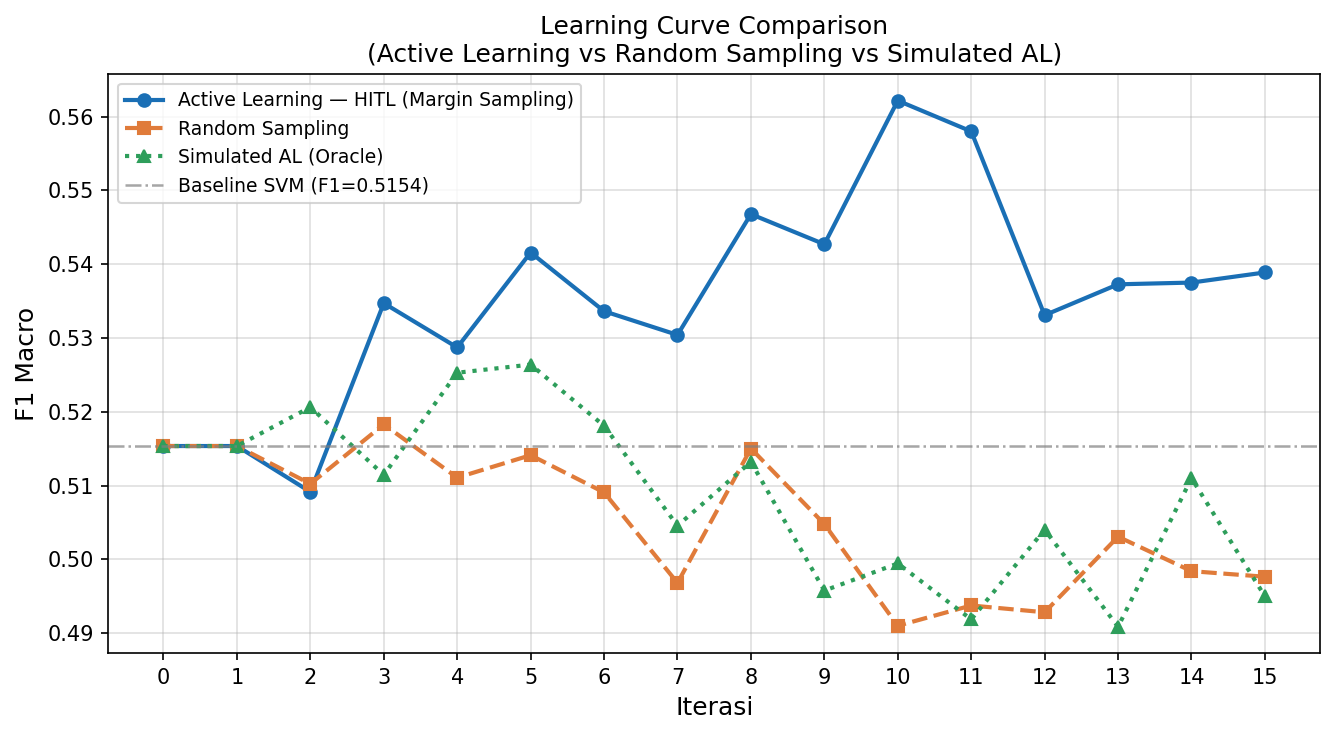

In [16]:
# =============================================================================
# CELL 15 — GRAFIK: LEARNING CURVE COMPARISON
# =============================================================================
# F1 Macro per iterasi untuk ketiga kondisi. Data dari CSV.
# =============================================================================

df_plot = pd.read_csv(f'{OUTPUT_DIR}/al_results_all.csv')

# Gaya visual konsisten di semua grafik
PLOT_STYLES = {
    'AL-HITL (Margin Sampling)': dict(
        marker='o', color='#1a6fb5', linewidth=2,
        label='Active Learning — HITL (Margin Sampling)'
    ),
    'Random Sampling': dict(
        marker='s', color='#e07b3a', linewidth=2, linestyle='--',
        label='Random Sampling'
    ),
    'Simulated AL (Oracle)': dict(
        marker='^', color='#2e9e5b', linewidth=2, linestyle=':',
        label='Simulated AL (Oracle)'
    ),
}

fig, ax = plt.subplots(figsize=(9, 5))
for condition, style in PLOT_STYLES.items():
    subset = df_plot[df_plot['condition'] == condition].sort_values('iteration')
    ax.plot(subset['iteration'], subset['f1_macro'], **style)

ax.axhline(y=baseline_metrics_svm['f1_macro'], color='gray', linestyle='-.',
           linewidth=1.2, alpha=0.7,
           label=f'Baseline SVM (F1={baseline_metrics_svm["f1_macro"]:.4f})')
ax.set_xlabel('Iterasi', fontsize=12)
ax.set_ylabel('F1 Macro', fontsize=12)
ax.set_title('Learning Curve Comparison\n'
             '(Active Learning vs Random Sampling vs Simulated AL)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
ax.set_xticks(range(0, N_ITER + 1))
plt.tight_layout()

save_path = f'{OUTPUT_DIR}/fig_learning_curve.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight')
print(f'✅ Grafik disimpan: {save_path}')
plt.show()


### 15.2 Label Efficiency Curve


✅ Grafik disimpan: results/fig_label_efficiency.png


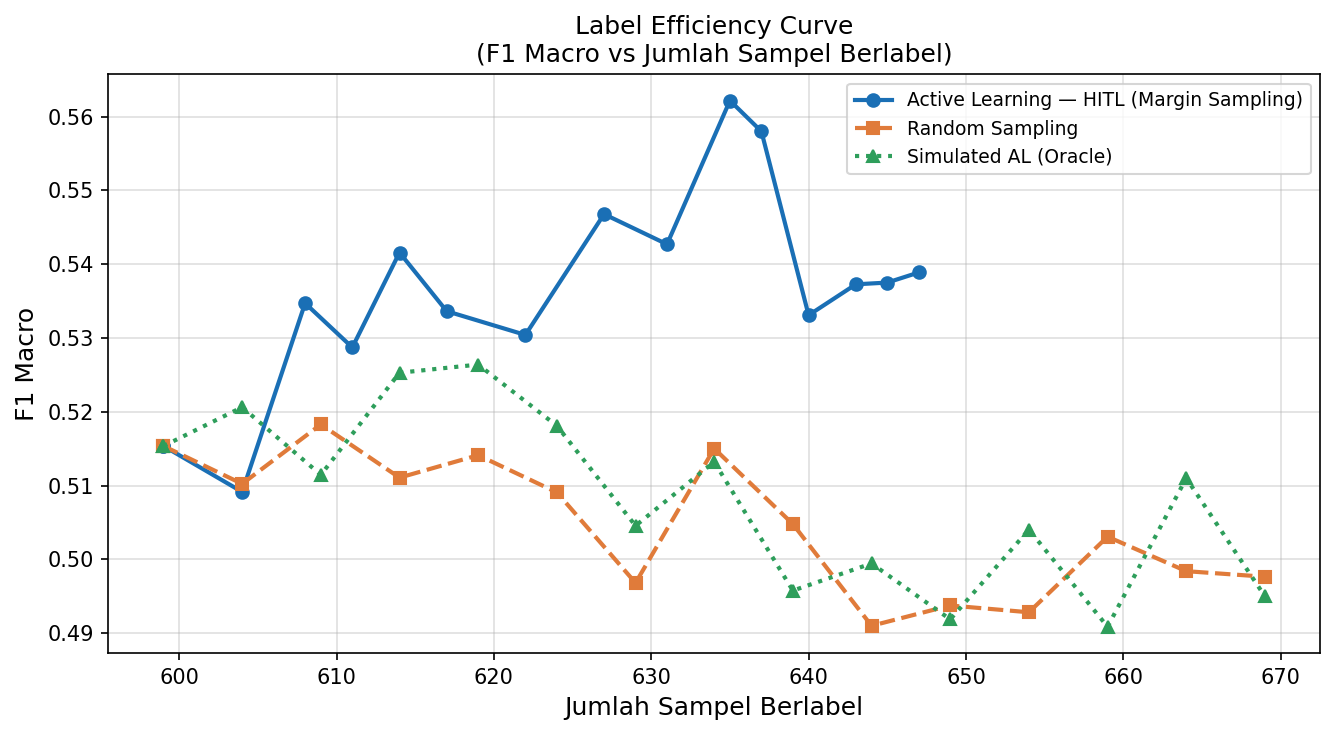

In [17]:
# =============================================================================
# CELL 16 — GRAFIK: LABEL EFFICIENCY CURVE
# =============================================================================
# F1 Macro sebagai fungsi jumlah sampel berlabel (bukan iterasi).
# Kurva lebih tinggi pada jumlah sampel sama = lebih efisien.
# =============================================================================

fig, ax = plt.subplots(figsize=(9, 5))
for condition, style in PLOT_STYLES.items():
    subset = df_plot[df_plot['condition'] == condition].sort_values('labeled_size')
    ax.plot(subset['labeled_size'], subset['f1_macro'], **style)

ax.set_xlabel('Jumlah Sampel Berlabel', fontsize=12)
ax.set_ylabel('F1 Macro', fontsize=12)
ax.set_title('Label Efficiency Curve\n(F1 Macro vs Jumlah Sampel Berlabel)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
plt.tight_layout()

save_path = f'{OUTPUT_DIR}/fig_label_efficiency.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight')
print(f'✅ Grafik disimpan: {save_path}')
plt.show()


### 15.3 F1 Score per Kelas (Model Iterasi Terakhir)


✅ Grafik disimpan: results/fig_f1_per_class.png


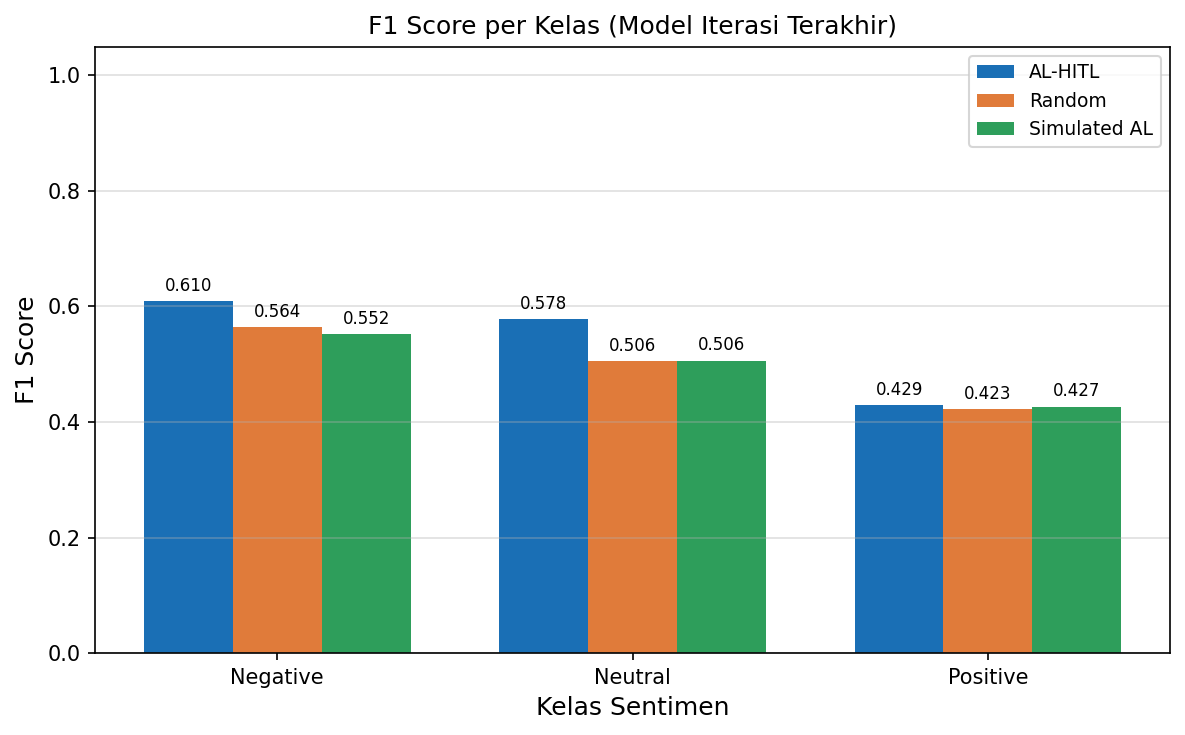


📊 F1 per Kelas (Iterasi Terakhir):


,Class,AL-HITL,Random,Simulated AL
0,Negative,0.6098,0.5644,0.5521
1,Neutral,0.5783,0.5060,0.5062
2,Positive,0.4286,0.4225,0.4267


In [18]:
# =============================================================================
# CELL 17 — GRAFIK: F1 PER KELAS (BAR CHART)
# =============================================================================
# Membandingkan F1 per kelas dari model iterasi terakhir ketiga kondisi.
# =============================================================================

best_al     = svm_al_models[-1]
best_random = svm_random_models[-1]
best_sim    = svm_sim_models[-1]

SENTIMENT_CLASSES = ['Negative', 'Neutral', 'Positive']
CLASS_KEYS        = ['neg', 'neu', 'pos']

f1_al_per_class     = [evaluate_model(best_al,     X_test_fixed, y_test_fixed, verbose=False)[f'f1_{k}'] for k in CLASS_KEYS]
f1_random_per_class = [evaluate_model(best_random, X_test_fixed, y_test_fixed, verbose=False)[f'f1_{k}'] for k in CLASS_KEYS]
f1_sim_per_class    = [evaluate_model(best_sim,    X_test_fixed, y_test_fixed, verbose=False)[f'f1_{k}'] for k in CLASS_KEYS]

x     = np.arange(len(SENTIMENT_CLASSES))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, f1_al_per_class,     width, label='AL-HITL',     color='#1a6fb5')
bars2 = ax.bar(x,         f1_random_per_class, width, label='Random',       color='#e07b3a')
bars3 = ax.bar(x + width, f1_sim_per_class,    width, label='Simulated AL', color='#2e9e5b')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Kelas Sentimen', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score per Kelas (Model Iterasi Terakhir)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(SENTIMENT_CLASSES)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()

save_path = f'{OUTPUT_DIR}/fig_f1_per_class.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight')
print(f'✅ Grafik disimpan: {save_path}')
plt.show()

# Tabel F1 per kelas untuk paper
df_class = pd.DataFrame({
    'Class':        SENTIMENT_CLASSES,
    'AL-HITL':      f1_al_per_class,
    'Random':       f1_random_per_class,
    'Simulated AL': f1_sim_per_class
})
print('\n📊 F1 per Kelas (Iterasi Terakhir):')
display(df_class.round(4))


### 15.4 Confusion Matrix


✅ Grafik disimpan: results/fig_confusion_matrix.png


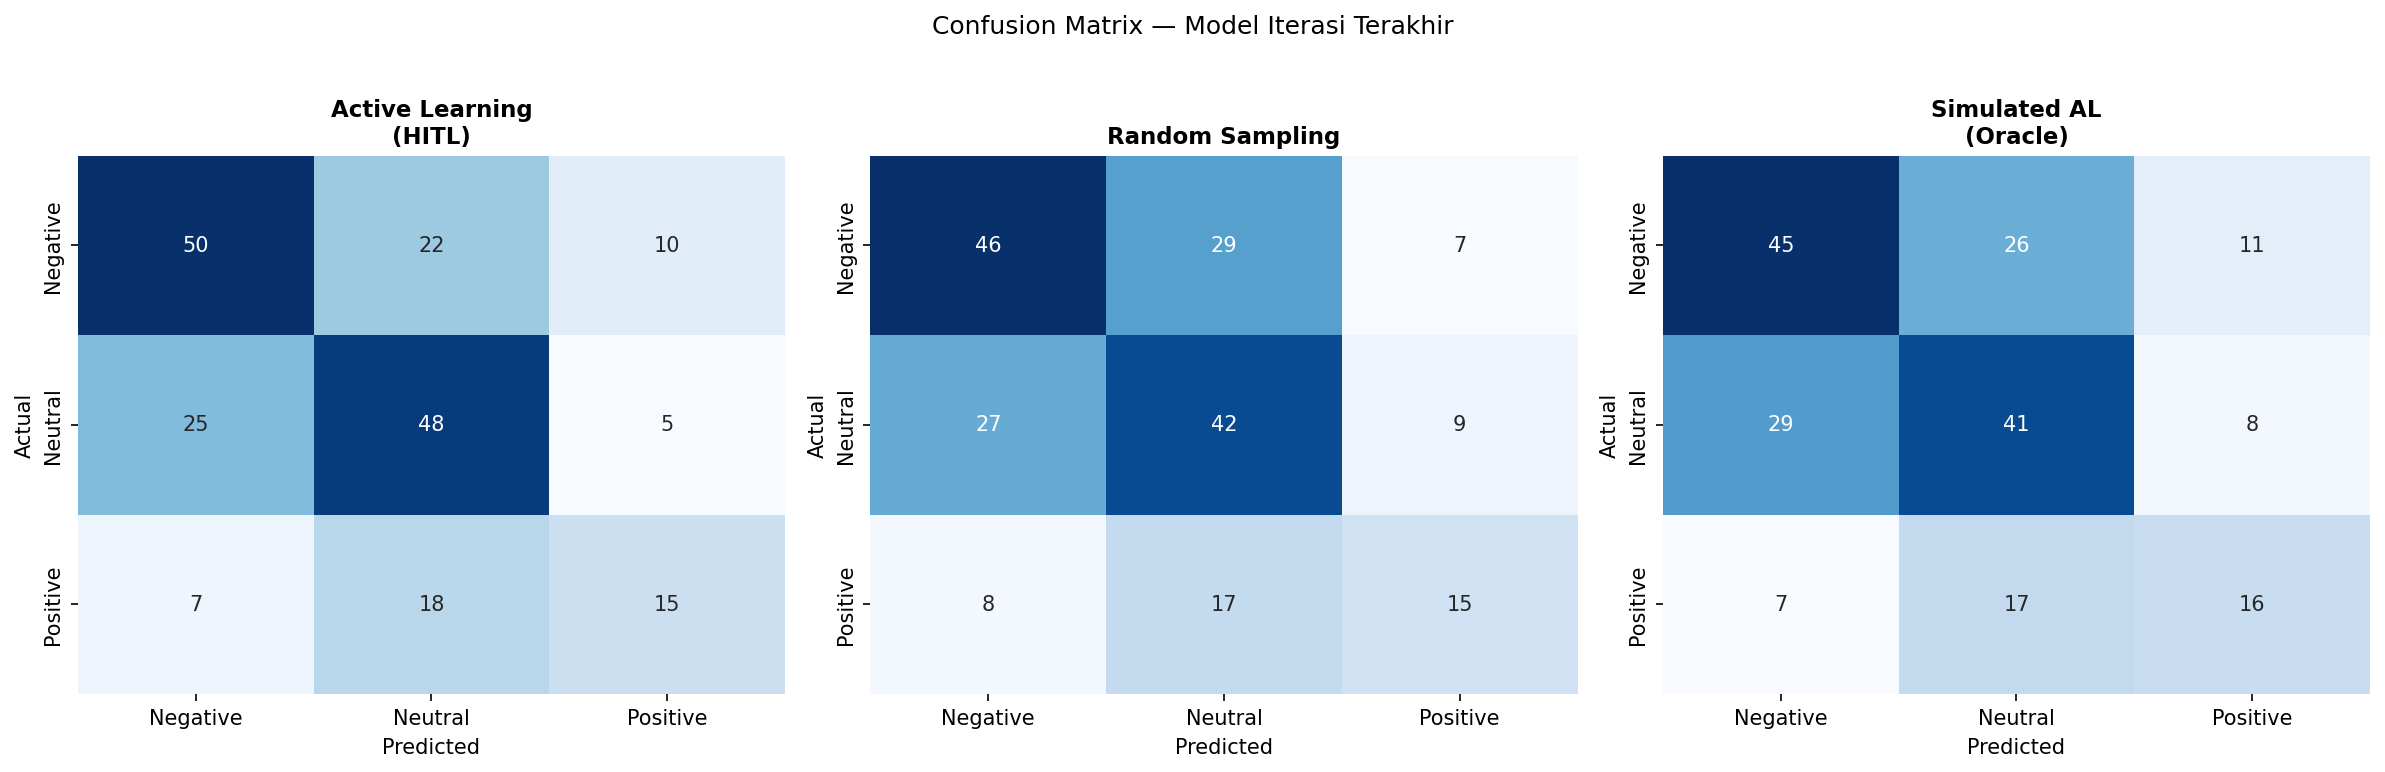

In [19]:
# =============================================================================
# CELL 18 — GRAFIK: CONFUSION MATRIX (3 KONDISI)
# =============================================================================

CLASS_NAMES = ['Negative', 'Neutral', 'Positive']
models_to_plot = {
    'Active Learning\n(HITL)':  best_al,
    'Random Sampling':           best_random,
    'Simulated AL\n(Oracle)':   best_sim,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, model) in zip(axes, models_to_plot.items()):
    y_pred = model.predict(X_test_fixed)
    cm = confusion_matrix(y_test_fixed, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=False)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

fig.suptitle('Confusion Matrix — Model Iterasi Terakhir', fontsize=12, y=1.02)
plt.tight_layout()

save_path = f'{OUTPUT_DIR}/fig_confusion_matrix.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight')
print(f'✅ Grafik disimpan: {save_path}')
plt.show()


### 15.5 Class-wise Learning Curve (AL-HITL)


✅ Grafik disimpan: results/fig_classwise_curve.png


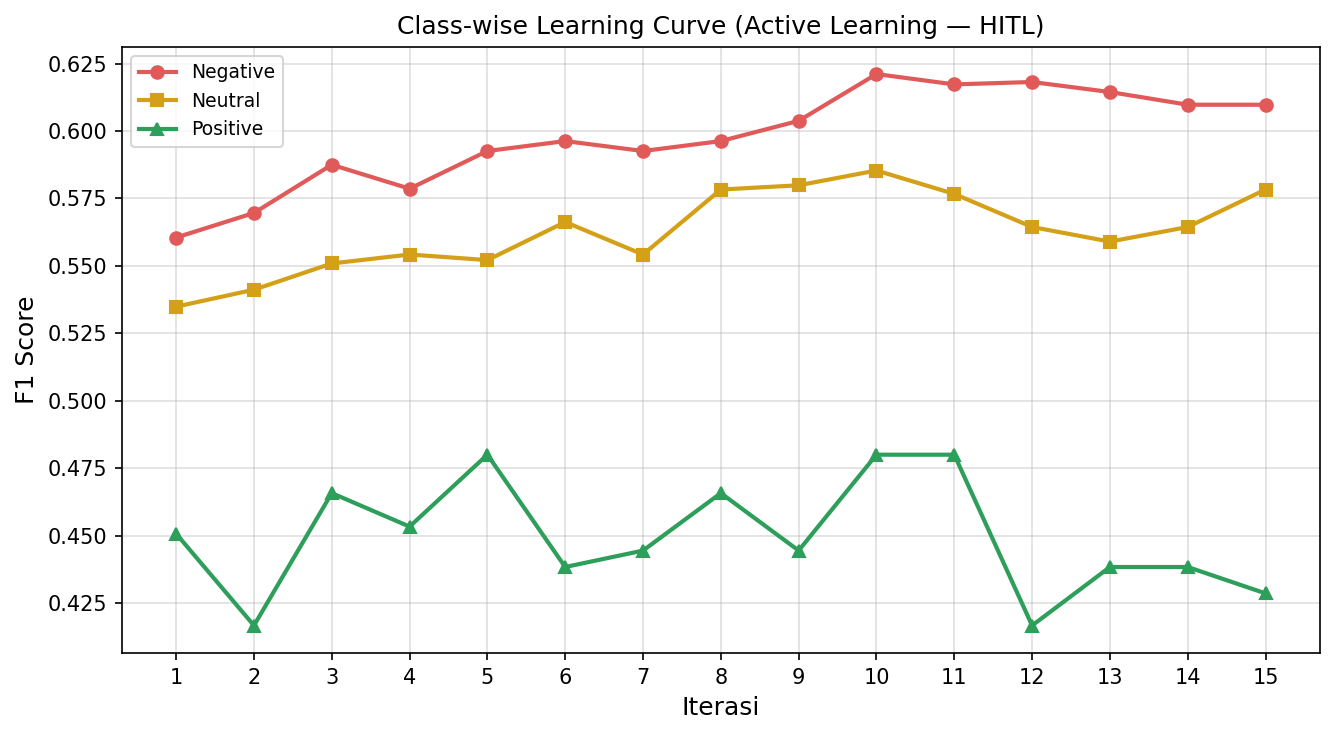

✅ Class-wise data disimpan: results/al_classwise_f1.csv


In [20]:
# =============================================================================
# CELL 19 — GRAFIK: CLASS-WISE LEARNING CURVE (AL-HITL)
# =============================================================================
# Perkembangan F1 per kelas sepanjang iterasi AL.
# Berguna untuk melihat apakah semua kelas meningkat atau hanya mayoritas.
# =============================================================================

f1_neg_history = []
f1_neu_history = []
f1_pos_history = []

for model_snapshot in svm_al_models:
    met = evaluate_model(model_snapshot, X_test_fixed, y_test_fixed, verbose=False)
    f1_neg_history.append(met['f1_neg'])
    f1_neu_history.append(met['f1_neu'])
    f1_pos_history.append(met['f1_pos'])

iteration_range = list(range(1, len(svm_al_models) + 1))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(iteration_range, f1_neg_history, marker='o', color='#e05a5a', linewidth=2, label='Negative')
ax.plot(iteration_range, f1_neu_history, marker='s', color='#d4a017', linewidth=2, label='Neutral')
ax.plot(iteration_range, f1_pos_history, marker='^', color='#2e9e5b', linewidth=2, label='Positive')

ax.set_xlabel('Iterasi', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Class-wise Learning Curve (Active Learning — HITL)', fontsize=12)
ax.legend(fontsize=9)
ax.set_xticks(iteration_range)
ax.grid(True, alpha=0.4)
plt.tight_layout()

save_path = f'{OUTPUT_DIR}/fig_classwise_curve.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight')
print(f'✅ Grafik disimpan: {save_path}')
plt.show()

# Simpan class-wise ke CSV
df_classwise = pd.DataFrame({
    'iteration': iteration_range,
    'f1_neg':    f1_neg_history,
    'f1_neu':    f1_neu_history,
    'f1_pos':    f1_pos_history,
})
df_classwise.to_csv(f'{OUTPUT_DIR}/al_classwise_f1.csv', index=False)
print(f'✅ Data class-wise disimpan: {OUTPUT_DIR}/al_classwise_f1.csv')


---
## 16. Eksperimen Multi Query Size

Menganalisis pengaruh `QUERY_SIZE` terhadap konvergensi AL dengan membandingkan
Q=5, Q=10, Q=20. Eksperimen ini menjawab pertanyaan reviewer:
*"Apakah QUERY_SIZE=5 terlalu kecil? Bagaimana pengaruhnya terhadap konvergensi?"*

Oracle sempurna digunakan (`noise_rate=0`) untuk mengisolasi efek query size.


In [21]:
# =============================================================================
# CELL 20 — FUNGSI AL LOOP GENERIK (MULTI QUERY SIZE)
# =============================================================================

def run_al_experiment(X_train, y_train, X_pool_data, y_pool_oracle,
                      X_test, y_test,
                      query_size, n_iter,
                      noise_rate=0.0, random_state=42, label='AL'):
    """
    Menjalankan satu eksperimen Active Learning dengan konfigurasi tertentu.

    Menggunakan Pure Margin Sampling konsisten dengan eksperimen utama.
    noise_rate=0.0 -> oracle sempurna (untuk isolasi efek query size).
    noise_rate>0.0 -> simulasi annotator manusia dengan kesalahan.

    Args:
        X_train        : Sparse matrix data training awal.
        y_train        : Label training awal.
        X_pool_data    : Sparse matrix pool kandidat.
        y_pool_oracle  : Label oracle pool.
        X_test         : Sparse matrix test set tetap.
        y_test         : Label test set.
        query_size     : Jumlah sampel dipilih per iterasi.
        n_iter         : Jumlah maksimum iterasi.
        noise_rate     : Probabilitas kesalahan label [0.0, 1.0].
        random_state   : Seed untuk reprodusibilitas.
        label          : Nama eksperimen untuk logging.

    Returns:
        history : List dict metrik evaluasi per iterasi.
        models  : List snapshot model per iterasi.
    """
    np.random.seed(random_state)

    X_lbl = X_train.copy()
    y_lbl = y_train.copy()
    X_unl = X_pool_data.copy()
    y_unl = y_pool_oracle.copy()

    model = SVC(
        kernel='linear', C=1.0,
        class_weight='balanced',
        probability=True,
        random_state=random_state
    )

    history = []
    models  = []

    for i in range(n_iter):
        model.fit(X_lbl, y_lbl)
        models.append(copy.deepcopy(model))

        met = evaluate_model(
            model, X_test, y_test,
            model_name=f'{label} q{query_size} iter{i + 1}',
            verbose=False
        )
        met['iteration']    = i + 1
        met['labeled_size'] = X_lbl.shape[0]
        met['query_size']   = query_size
        history.append(met)

        if X_unl.shape[0] < query_size:
            break

        # Pure Margin Sampling
        q_idx = svm_margin_sampling(model, X_unl, n_samples=query_size)

        # Labeling dengan noise (noise_rate=0 = oracle sempurna)
        rng        = np.random.default_rng(random_state + i)
        new_labels = []
        for idx in q_idx:
            true_label = int(y_unl[idx])
            if rng.random() < noise_rate:
                other_classes = [c for c in [0, 1, 2] if c != true_label]
                new_labels.append(int(rng.choice(other_classes)))
            else:
                new_labels.append(true_label)

        X_lbl = vstack([X_lbl, X_unl[q_idx]])
        y_lbl = np.concatenate([y_lbl, new_labels])

        mask        = np.ones(X_unl.shape[0], dtype=bool)
        mask[q_idx] = False
        X_unl = X_unl[mask]
        y_unl = y_unl[mask]

    return history, models


print('✅ run_al_experiment() siap digunakan (pure margin sampling)')


✅ run_al_experiment() siap (pure margin sampling)


In [22]:
# =============================================================================
# CELL 21 — JALANKAN EKSPERIMEN MULTI QUERY SIZE
# =============================================================================

QUERY_SIZES_TO_COMPARE = [5, 10, 20]
N_ITER_MULTI           = 15
results_multi          = {}

for qs in QUERY_SIZES_TO_COMPARE:
    print(f'\n🔁 Pure Margin Sampling — QUERY_SIZE={qs}...')
    history, _ = run_al_experiment(
        X_train_base, y_train_base,
        X_pool, y_pool,
        X_test_fixed, y_test_fixed,
        query_size=qs,
        n_iter=N_ITER_MULTI,
        noise_rate=0.0,             # Oracle sempurna untuk isolasi efek query size
        random_state=RANDOM_STATE,
        label='AL'
    )
    results_multi[qs] = history
    f1_final = history[-1]['f1_macro']
    f1_delta = f1_final - baseline_metrics_svm['f1_macro']
    print(f'   F1 akhir : {f1_final:.4f}  (delta={f1_delta:+.4f} dari baseline)')

print('\n✅ Eksperimen multi query size selesai')



🔁 Pure Margin Sampling — QUERY_SIZE=5 ...
   F1 akhir: 0.4950  (Δ=-0.0204)

🔁 Pure Margin Sampling — QUERY_SIZE=10 ...
   F1 akhir: 0.5081  (Δ=-0.0073)

🔁 Pure Margin Sampling — QUERY_SIZE=20 ...
   F1 akhir: 0.5212  (Δ=+0.0058)

✅ Multi query size selesai


### 16.1 Visualisasi Pengaruh Query Size


✅ Grafik disimpan: results/fig_query_size_comparison.png


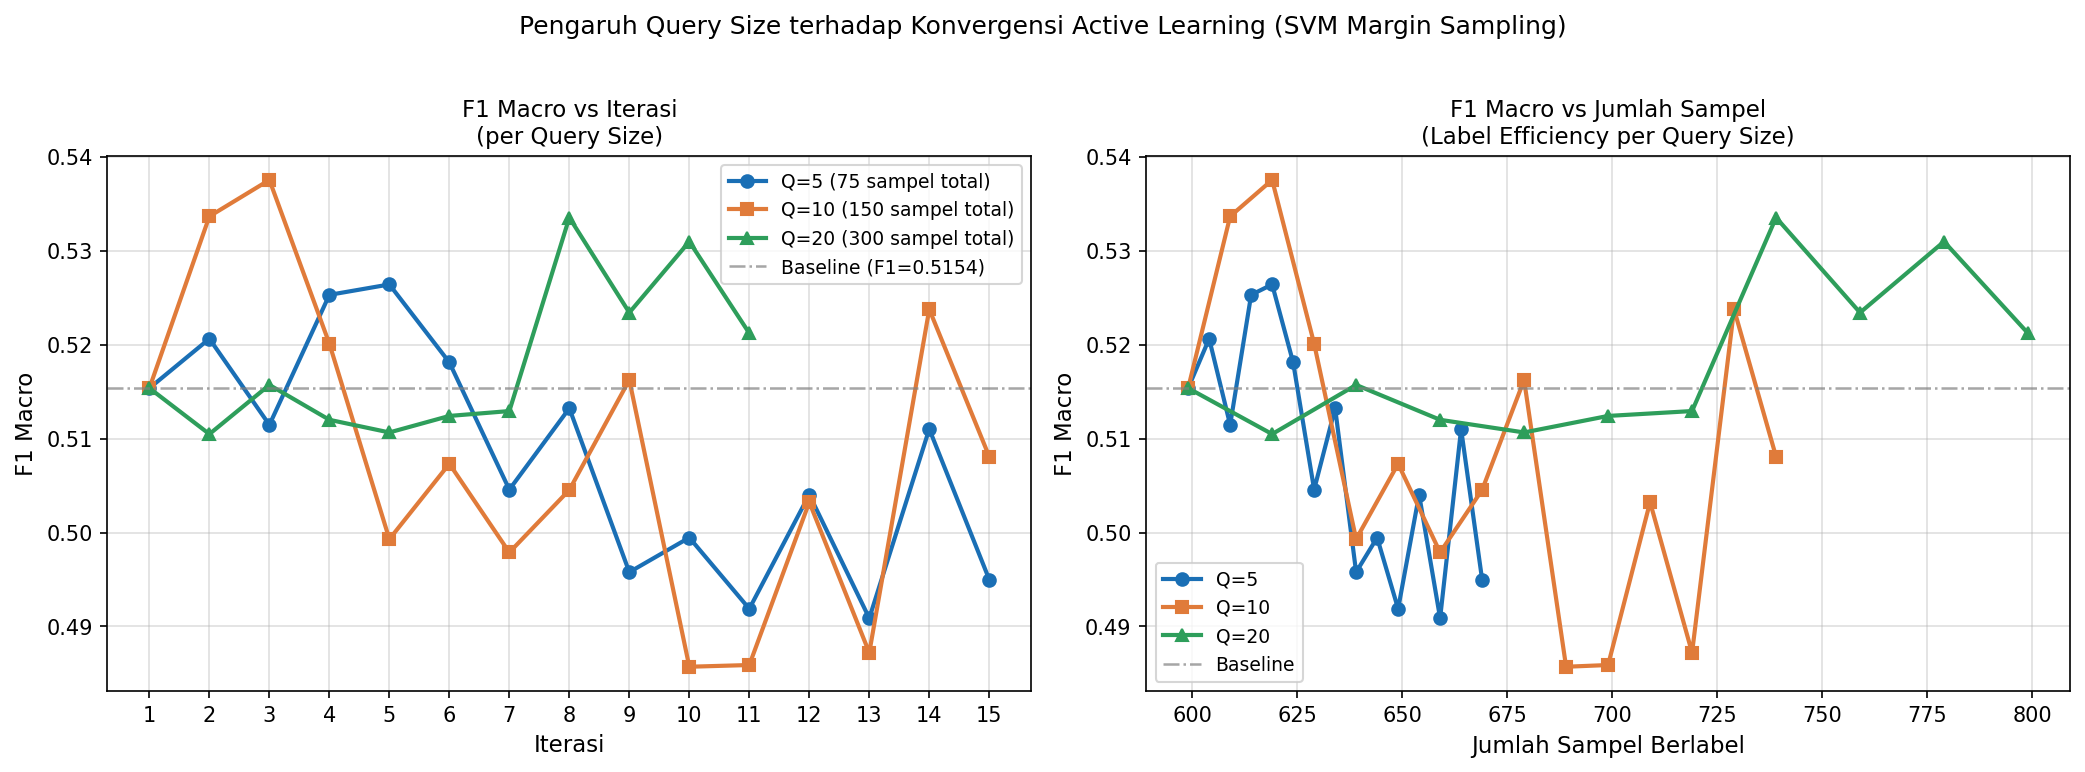

In [23]:
# =============================================================================
# CELL 22 — GRAFIK: PENGARUH QUERY SIZE
# =============================================================================
# Panel kiri: F1 vs Iterasi
# Panel kanan: F1 vs Jumlah Sampel (efisiensi per-sampel)
# =============================================================================

QS_COLORS  = {5: '#1a6fb5', 10: '#e07b3a', 20: '#2e9e5b'}
QS_MARKERS = {5: 'o', 10: 's', 20: '^'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel kiri: F1 vs Iterasi
ax = axes[0]
for qs, hist in results_multi.items():
    iters = [h['iteration'] for h in hist]
    f1s   = [h['f1_macro']  for h in hist]
    ax.plot(iters, f1s, marker=QS_MARKERS[qs], color=QS_COLORS[qs],
            linewidth=2, label=f'Q={qs} ({qs * N_ITER_MULTI} sampel total)')
ax.axhline(y=baseline_metrics_svm['f1_macro'], color='gray', linestyle='-.',
           linewidth=1.2, alpha=0.7,
           label=f'Baseline (F1={baseline_metrics_svm["f1_macro"]:.4f})')
ax.set_xlabel('Iterasi', fontsize=11)
ax.set_ylabel('F1 Macro', fontsize=11)
ax.set_title('F1 Macro vs Iterasi\n(per Query Size)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
ax.set_xticks(range(1, N_ITER_MULTI + 1))

# Panel kanan: F1 vs Jumlah Sampel (label efficiency)
ax = axes[1]
for qs, hist in results_multi.items():
    sizes = [h['labeled_size'] for h in hist]
    f1s   = [h['f1_macro']     for h in hist]
    ax.plot(sizes, f1s, marker=QS_MARKERS[qs], color=QS_COLORS[qs],
            linewidth=2, label=f'Q={qs}')
ax.axhline(y=baseline_metrics_svm['f1_macro'], color='gray', linestyle='-.',
           linewidth=1.2, alpha=0.7, label='Baseline')
ax.set_xlabel('Jumlah Sampel Berlabel', fontsize=11)
ax.set_ylabel('F1 Macro', fontsize=11)
ax.set_title('F1 Macro vs Jumlah Sampel\n(Label Efficiency per Query Size)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

fig.suptitle('Pengaruh Query Size terhadap Konvergensi Active Learning\n'
             '(SVM Margin Sampling, oracle sempurna)', fontsize=12, y=1.02)
plt.tight_layout()

save_path = f'{OUTPUT_DIR}/fig_query_size_comparison.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight')
print(f'✅ Grafik disimpan: {save_path}')
plt.show()


### 16.2 Tabel Ringkasan Multi Query Size


In [24]:
# =============================================================================
# CELL 23 — TABEL RINGKASAN MULTI QUERY SIZE
# =============================================================================

print('📊 Ringkasan Hasil Multi Query Size (Iterasi Terakhir)\n')

summary_rows = []
for qs, hist in results_multi.items():
    first_iter = hist[0]
    last_iter  = hist[-1]
    f1_delta   = last_iter['f1_macro'] - baseline_metrics_svm['f1_macro']
    n_extra    = last_iter['labeled_size'] - X_train_base.shape[0]
    summary_rows.append({
        'Query Size':            qs,
        'Total Sampel Tambahan': n_extra,
        'F1 Baseline':           round(baseline_metrics_svm['f1_macro'], 4),
        'F1 Iterasi 1':          round(first_iter['f1_macro'], 4),
        'F1 Akhir':              round(last_iter['f1_macro'], 4),
        'Delta F1':              round(f1_delta, 4),
        'F1/Sampel (efisiensi)': round(f1_delta / n_extra, 6) if n_extra > 0 else 0,
    })

df_query_size_summary = pd.DataFrame(summary_rows)
display(df_query_size_summary)

csv_qs_path = f'{OUTPUT_DIR}/multi_querysize_results.csv'
df_query_size_summary.to_csv(csv_qs_path, index=False)
print(f'\n✅ Tabel disimpan: {csv_qs_path}')

print('\n💡 Panduan Interpretasi:')
print('   Q kecil (5)  -> konvergensi lambat, tapi efisiensi per-sampel bisa lebih tinggi')
print('   Q besar (20) -> konvergensi cepat, tapi mungkin over-label di boundary yang sama')
print('   Kolom F1/Sampel = ukuran efisiensi nyata untuk perbandingan antar konfigurasi')


📊 Ringkasan Hasil Multi Query Size (Iterasi Terakhir)



,Query Size,Total Sampel Tambahan,F1 Baseline,F1 Iterasi 1,F1 Akhir,Delta F1,F1/Sampel (efisiensi)
0,5,70,0.5154,0.5154,0.4950,-0.0204,-0.000291
1,10,140,0.5154,0.5154,0.5081,-0.0073,-0.000052
2,20,200,0.5154,0.5154,0.5212,0.0058,0.000029



✅ Tabel disimpan: results/multi_querysize_results.csv

💡 Interpretasi:
   - Query size kecil (Q=5)  → konvergensi lambat tapi efisiensi per-sampel bisa lebih tinggi
   - Query size besar (Q=20) → konvergensi cepat tapi mungkin over-label pada region boundary yang sama
   - Kolom F1/Sampel = ukuran efisiensi nyata untuk dibandingkan antar konfigurasi


---
## 17. Ringkasan Akhir Eksperimen

Tabel komprehensif untuk semua angka yang dilaporkan di paper.
**Gunakan nilai dari sel ini** — bukan dari output sel individual —
untuk memastikan konsistensi antara teks, tabel, dan grafik di paper.


In [25]:
# =============================================================================
# CELL 24 — RINGKASAN AKHIR EKSPERIMEN (SINGLE SOURCE OF TRUTH)
# =============================================================================
# Semua angka untuk paper diambil dari sini — data dibaca dari CSV.
# =============================================================================

df_summary = pd.read_csv(f'{OUTPUT_DIR}/al_results_all.csv')


def get_metrics_at_iteration(condition, iteration):
    """
    Mengambil baris metrik untuk kondisi dan iterasi tertentu.

    Args:
        condition : Nama kondisi eksperimen.
        iteration : Nomor iterasi (0 = baseline).

    Returns:
        pd.Series atau None jika data tidak ditemukan.
    """
    mask = (df_summary['condition'] == condition) & (df_summary['iteration'] == iteration)
    row  = df_summary[mask]
    return row.iloc[0] if len(row) > 0 else None


print('=' * 70)
print('RINGKASAN EKSPERIMEN — SINGLE SOURCE OF TRUTH')
print('Gunakan nilai dari tabel ini untuk paper (konsisten dengan grafik).')
print('=' * 70)

# --- Tabel F1 Macro pada iterasi kunci ---------------------------------------
print('\n📊 F1 Macro pada Iterasi Kunci:')
key_iterations = [0, 3, 5, 8, 10, 12, N_ITER]
summary_rows   = []

for it in key_iterations:
    r_al  = get_metrics_at_iteration('AL-HITL (Margin Sampling)', it)
    r_ran = get_metrics_at_iteration('Random Sampling', it)
    r_sim = get_metrics_at_iteration('Simulated AL (Oracle)', it)
    summary_rows.append({
        'Iterasi':               it,
        'Labeled Size':          int(r_al['labeled_size']) if r_al is not None else '-',
        'AL-HITL (Margin)':      f'{r_al["f1_macro"]:.4f}'  if r_al is not None else '-',
        'Simulated AL (Oracle)': f'{r_sim["f1_macro"]:.4f}' if r_sim is not None else '-',
        'Random Sampling':       f'{r_ran["f1_macro"]:.4f}' if r_ran is not None else '-',
    })
display(pd.DataFrame(summary_rows))

# --- Tabel F1 per kelas (iterasi terakhir) -----------------------------------
print('\n📊 F1 per Kelas (Iterasi Terakhir):')
display(df_class.round(4))

# --- Efisiensi pelabelan -----------------------------------------------------
r_al_start  = get_metrics_at_iteration('AL-HITL (Margin Sampling)', 0)
r_al_end    = get_metrics_at_iteration('AL-HITL (Margin Sampling)', N_ITER)
r_ran_end   = get_metrics_at_iteration('Random Sampling', N_ITER)
r_ran_start = get_metrics_at_iteration('Random Sampling', 0)

if r_al_start is not None and r_al_end is not None:
    delta_al         = r_al_end['f1_macro']  - r_al_start['f1_macro']
    delta_ran        = r_ran_end['f1_macro'] - r_ran_start['f1_macro']
    efficiency_ratio = delta_al / delta_ran if delta_ran > 0 else float('inf')
    n_samples_added  = int(r_al_end['labeled_size']) - int(r_al_start['labeled_size'])

    print('\n📊 Efisiensi Pelabelan:')
    print(f'   Delta F1 Macro AL-HITL   : {delta_al:+.4f}')
    print(f'   Delta F1 Macro Random    : {delta_ran:+.4f}')
    print(f'   Rasio efisiensi AL       : {efficiency_ratio:.2f}x lebih efisien dari Random')
    print(f'   Sampel tambahan          : {n_samples_added} sampel (iterasi 1-{N_ITER})')

# --- Ringkasan file output ---------------------------------------------------
print(f'\n📂 File output tersimpan di folder: {OUTPUT_DIR}/')
output_files = [
    ('al_results_all.csv',          'Metrik semua kondisi dan iterasi'),
    ('al_classwise_f1.csv',         'F1 per kelas per iterasi (AL-HITL)'),
    ('multi_querysize_results.csv', 'Hasil eksperimen multi query size'),
    ('fig_learning_curve.png',      'Learning curve comparison'),
    ('fig_label_efficiency.png',    'Label efficiency curve'),
    ('fig_f1_per_class.png',        'F1 per kelas bar chart'),
    ('fig_confusion_matrix.png',    'Confusion matrix 3 kondisi'),
    ('fig_classwise_curve.png',     'Class-wise learning curve'),
    ('fig_query_size_comparison.png', 'Pengaruh query size'),
]
for fname, desc in output_files:
    print(f'   {fname:<38} <- {desc}')


RINGKASAN EKSPERIMEN — SINGLE SOURCE OF TRUTH
Gunakan nilai dari tabel ini untuk paper (konsisten dengan grafik)

📊 F1 Macro per Iterasi Kunci:


,Iterasi,Labeled Size,AL-HITL (Margin),Simulated AL,Random
0,0,599,0.5154,0.5154,0.5154
1,3,608,0.5347,0.5115,0.5183
2,5,614,0.5416,0.5264,0.5141
3,8,627,0.5468,0.5132,0.5150
4,10,635,0.5622,0.4995,0.4910
5,12,640,0.5331,0.5040,0.4928
6,15,647,0.5389,0.4950,0.4977



📊 F1 per Kelas (Iterasi Terakhir):


,Class,AL-HITL,Random,Simulated AL
0,Negative,0.6098,0.5644,0.5521
1,Neutral,0.5783,0.5060,0.5062
2,Positive,0.4286,0.4225,0.4267



📊 Efisiensi Pelabelan:
   Δ F1 Macro AL-HITL  : +0.0235
   Δ F1 Macro Random   : -0.0177
   Rasio efisiensi AL  : infx lebih efisien
   Sampel tambahan     : 48 sampel

📂 Semua file tersimpan di folder: results/
   al_results_all.csv     → source of truth semua iterasi
   al_classwise_f1.csv    → F1 per kelas per iterasi (AL)
   fig_learning_curve.png
   fig_label_efficiency.png
   fig_f1_per_class.png
   fig_confusion_matrix.png
   fig_classwise_curve.png
